# Financial News Sentiment Prediction using Deep Learning & BERT

---

## Project Overview

This notebook builds a **3-class sentiment classification system** for finance-related tweets,
labelling each tweet as:
- **Bearish** — pessimistic / negative market outlook
- **Bullish** — optimistic / positive market outlook
- **Neutral** — objective or mixed sentiment

**Dataset:** [Twitter Financial News Sentiment](https://huggingface.co/datasets/zeroshot/twitter-financial-news-sentiment) (Hugging Face)  
**Total samples:** 11,932 tweets | Train: 9,938 | Validation: 2,486

**Models trained:**
1. Embedding + Simple RNN (baseline)
2. Embedding + LSTM
3. Embedding + GRU
4. Fine-tuned FinBERT (`ProsusAI/finbert`) — optional GPU step

**Evaluation:** Accuracy, Macro F1-Score, Class-wise Precision/Recall, Confusion Matrix

---

### Notebook Structure

| # | Section | Key Output |
|---|---------|-----------|
| 1 | Setup & Imports | Library validation |
| 2 | Data Loading & EDA | Class distribution, word/ticker analysis |
| 3 | Text Preprocessing | Cleaned tokens for RNN; light-clean for BERT |
| 4 | Vocabulary & Tensor Prep | word2idx, padded tensors, class weights |
| 5 | RNN Architectures | SimpleRNN, LSTM, GRU model classes |
| 6 | Training Loop | Early stopping, training curves |
| 7 | Model Evaluation | Reports, confusion matrices, error analysis |
| 8 | FinBERT Fine-tuning | GPU step + pre-recorded results |
| 9 | Inference Pipeline | predict_sentiment() + paragraph analysis |
| 10 | Final Summary | Consolidated comparison table |


## Section 1 — Setup & Imports

We import all libraries up front for clarity and reproducibility. PyTorch is used for model building and training; Hugging Face `datasets` and `transformers` for data loading and BERT; scikit-learn provides evaluation metrics.

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import re
import json
import pickle
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

# ── Scientific stack ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── NLP utilities ─────────────────────────────────────────────────────────────
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem   import WordNetLemmatizer

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── Hugging Face ──────────────────────────────────────────────────────────────
from datasets import load_dataset

# ── Evaluation ────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

# ── Global settings ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

print(f"PyTorch version  : {torch.__version__}")
print(f"Device           : {device}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
print("\n✓ All libraries imported successfully.")


PyTorch version  : 2.12.0.dev20260408+cu128
Device           : cuda
CUDA available   : True
GPU              : NVIDIA GeForce RTX 5060 Laptop GPU

✓ All libraries imported successfully.


## Section 2 — Data Loading & Exploratory Data Analysis

### 2.1 Load Dataset

We use the official Hugging Face dataset `zeroshot/twitter-financial-news-sentiment`
with the **sentiment** configuration:

| Label ID | Label Name | Meaning |
|----------|-----------|---------|
| 0 | Bearish | Negative / pessimistic market outlook |
| 1 | Bullish | Positive / optimistic market outlook |
| 2 | Neutral | Objective / factual / mixed |

**Only the official `train` and `validation` splits are used — no test leakage.**


In [2]:
# ── Load dataset directly from Hugging Face ───────────────────────────────────
dataset = load_dataset('zeroshot/twitter-financial-news-sentiment')

train_df = dataset['train'].to_pandas()
valid_df = dataset['validation'].to_pandas()

LABEL_MAP   = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
NUM_CLASSES = 3

train_df['label_name'] = train_df['label'].map(LABEL_MAP)
valid_df['label_name'] = valid_df['label'].map(LABEL_MAP)

print("Dataset loaded successfully.")
print(f"Train shape      : {train_df.shape}")
print(f"Validation shape : {valid_df.shape}")
print(f"\nFirst 5 training rows:")
display(train_df.head())


Dataset loaded successfully.
Train shape      : (9543, 3)
Validation shape : (2388, 3)

First 5 training rows:


,text,label,label_name
0,$BYND - JPMorgan reels in expectations on Beyo...,0,Bearish
1,$CCL $RCL - Nomura points to bookings weakness...,0,Bearish
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0,Bearish
3,$ESS: BTIG Research cuts to Neutral https://t....,0,Bearish
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0,Bearish


### 2.2 Data Quality Checks

Before modelling we verify: no null values, no within-split duplicates, and — critically — **no data leakage** (the same tweet appearing in both train and validation).

In [3]:
# ── Null values ───────────────────────────────────────────────────────────────
print("NULL VALUES")
print(f"  Train : {train_df.isnull().sum().sum()} total nulls")
print(f"  Valid : {valid_df.isnull().sum().sum()} total nulls")

# ── Duplicates within each split ──────────────────────────────────────────────
train_dups = train_df.duplicated(subset='text').sum()
valid_dups = valid_df.duplicated(subset='text').sum()
print(f"\nDUPLICATE TEXTS")
print(f"  Train : {train_dups}")
print(f"  Valid : {valid_dups}")

# ── Data leakage check ────────────────────────────────────────────────────────
overlap = pd.merge(train_df[['text']], valid_df[['text']], on='text', how='inner')
print(f"\nDATA LEAKAGE CHECK")
print(f"  Texts in both splits : {len(overlap)}")
if len(overlap) == 0:
    print("  ✓ No leakage — splits are fully disjoint.")
else:
    print("  ⚠ WARNING: leakage detected!")


NULL VALUES
  Train : 0 total nulls
  Valid : 0 total nulls

DUPLICATE TEXTS
  Train : 0
  Valid : 0

DATA LEAKAGE CHECK
  Texts in both splits : 0
  ✓ No leakage — splits are fully disjoint.


### 2.3 Class Distribution

The dataset is **heavily imbalanced**: Neutral dominates at ~65%, while Bearish is the minority at ~15%. This 4.3× imbalance will be handled with class-weighted loss during training.

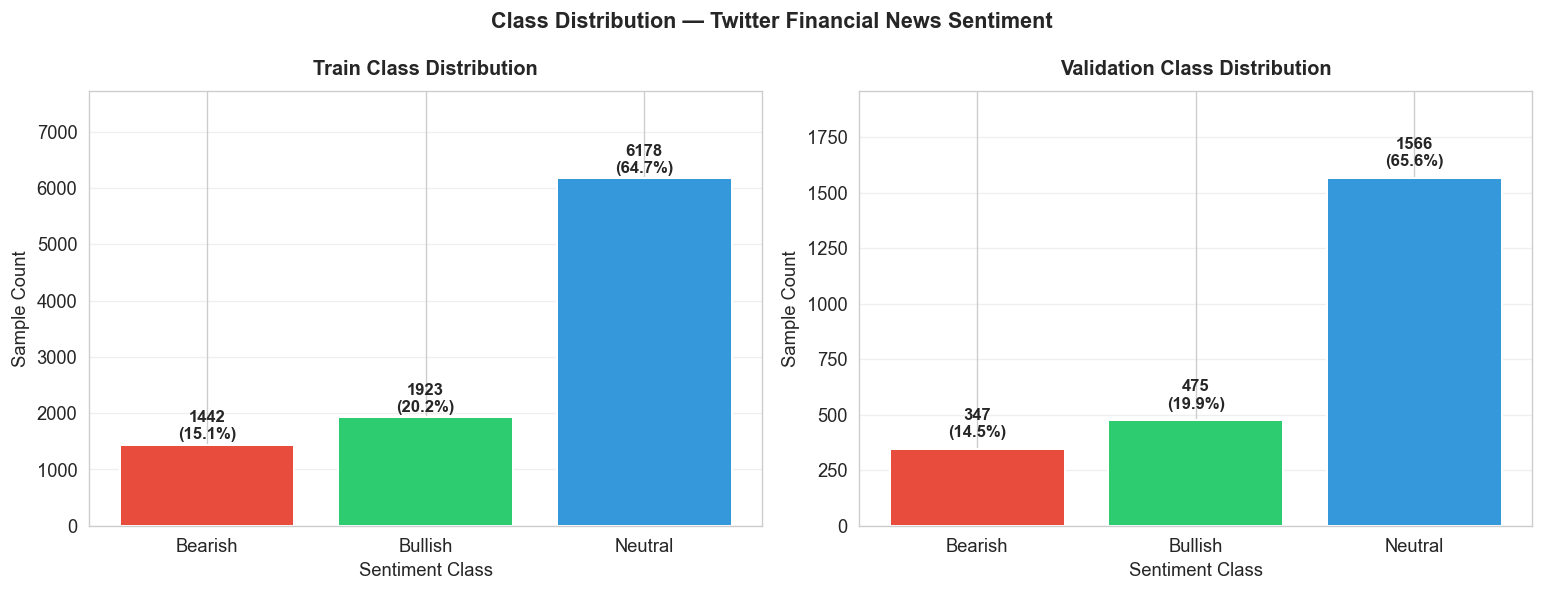

In [4]:
# ── Class counts and visual ───────────────────────────────────────────────────
LABEL_ORDER = ['Bearish', 'Bullish', 'Neutral']
COLORS      = ['#e74c3c', '#2ecc71', '#3498db']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, split in zip(axes, [train_df, valid_df], ['Train', 'Validation']):
    dist = df['label_name'].value_counts().reindex(LABEL_ORDER)
    pct  = dist / len(df) * 100
    bars = ax.bar(LABEL_ORDER, dist.values, color=COLORS, edgecolor='white', linewidth=1.2)
    for bar, count, p in zip(bars, dist.values, pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
                f"{count}\n({p:.1f}%)", ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.set_title(f"{split} Class Distribution", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Sentiment Class')
    ax.set_ylabel('Sample Count')
    ax.set_ylim(0, dist.max() * 1.25)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Class Distribution — Twitter Financial News Sentiment',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Key insight: Neutral is 4.3× more frequent than Bearish.

Class-weighted CrossEntropyLoss will compensate during training.

In [7]:
eda_results = {}

train_dist = (
    train_df["label_name"]
    .value_counts()
    .reindex(LABEL_ORDER)
    .to_dict()
)

valid_dist = (
    valid_df["label_name"]
    .value_counts()
    .reindex(LABEL_ORDER)
    .to_dict()
)

eda_results["class_distribution"] = {
    "train": train_dist,
    "validation": valid_dist
}

### 2.4 Tweet Length Analysis

Understanding tweet length helps choose `MAX_SEQUENCE_LENGTH`. The 95th-percentile word count informs the truncation threshold.

Train — Word Count Statistics by Class:
             count   mean   std  min  25%   50%   75%   max
label_name                                                 
Bearish     1442.0  12.00  4.31  3.0  9.0  11.0  15.0  32.0
Bullish     1923.0  11.93  4.32  2.0  9.0  11.0  14.0  29.0
Neutral     6178.0  12.30  4.84  1.0  9.0  12.0  16.0  29.0

95th percentile : 21 words
Maximum         : 32 words

→ MAX_SEQUENCE_LENGTH = 32 safely covers all tweets (max=32)


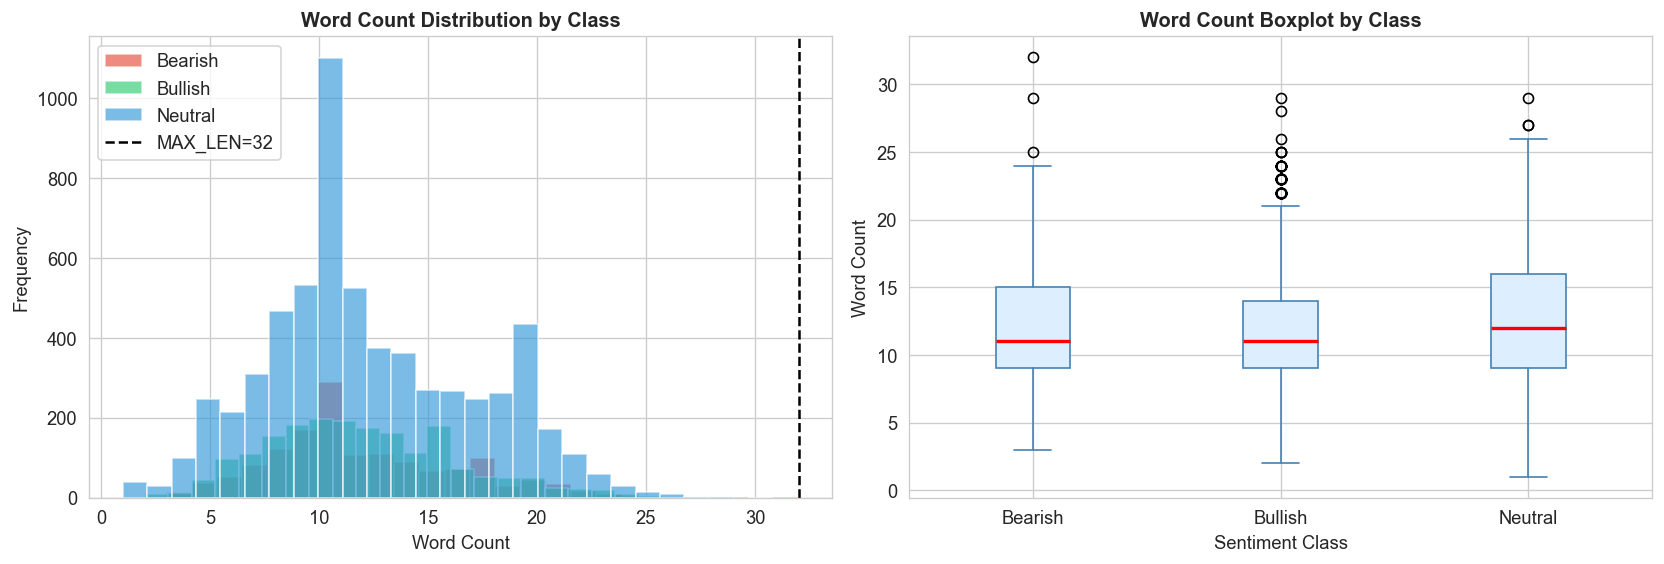

In [8]:
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))
train_df['char_count'] = train_df['text'].apply(len)

print("Train — Word Count Statistics by Class:")
print(train_df.groupby('label_name')['word_count'].describe().round(2))
print()
p95  = train_df['word_count'].quantile(0.95)
pmax = train_df['word_count'].max()
print(f"95th percentile : {p95:.0f} words")
print(f"Maximum         : {pmax} words")
print(f"\n→ MAX_SEQUENCE_LENGTH = 32 safely covers all tweets (max={pmax})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label_id, label_name, color in zip([0,1,2], LABEL_ORDER, COLORS):
    subset = train_df[train_df['label'] == label_id]['word_count']
    axes[0].hist(subset, bins=25, alpha=0.65, label=label_name, color=color, edgecolor='white')

axes[0].set_title('Word Count Distribution by Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(32, color='black', linestyle='--', linewidth=1.5, label='MAX_LEN=32')
axes[0].legend()

train_df.boxplot(
    column='word_count', by='label_name', ax=axes[1],
    patch_artist=True,
    boxprops=dict(facecolor='#ddeeff', color='steelblue'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='steelblue'),
    capprops=dict(color='steelblue')
)
axes[1].set_title('Word Count Boxplot by Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment Class')
axes[1].set_ylabel('Word Count')
plt.suptitle('')
plt.tight_layout()
plt.show()


### 2.5 Most Frequent Words Per Class

Examining per-class vocabulary reveals which words carry sentiment signal — and, critically, which stopwords to *keep* (e.g., *up*, *down*, *not*).

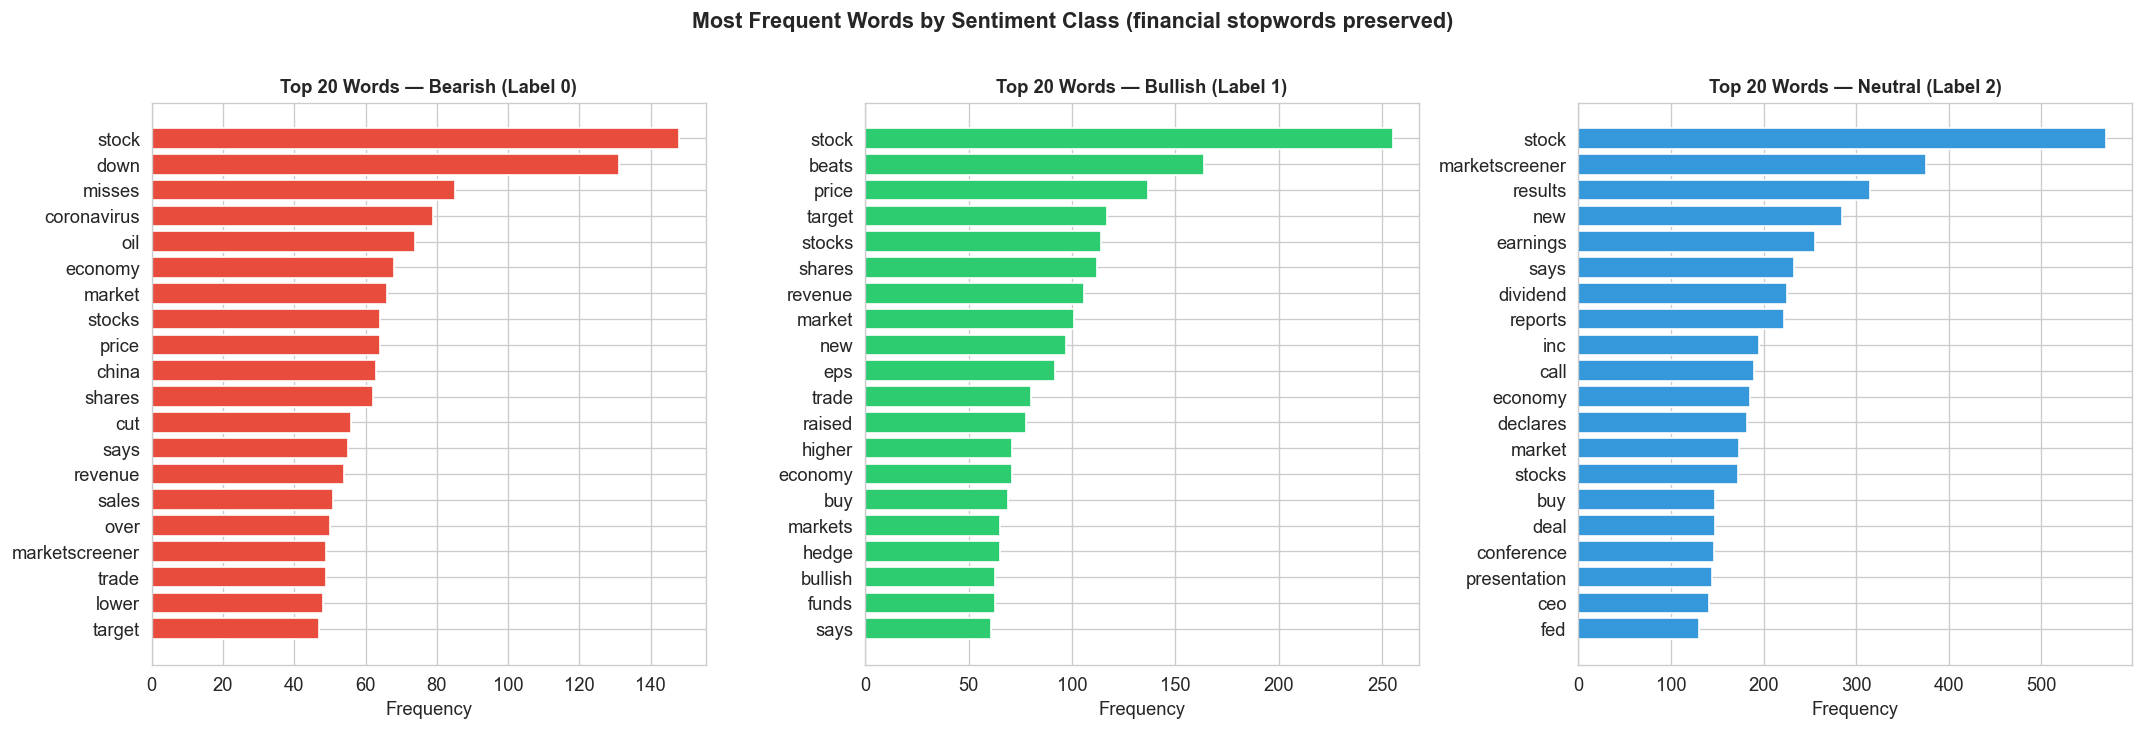

In [9]:
# ── Top words per sentiment class ─────────────────────────────────────────────
_STOP = set(stopwords.words('english'))
_KEEP = {'up', 'down', 'not', 'no', 'nor', 'against', 'below', 'above', 'under', 'over'}
_STOP = _STOP - _KEEP   # preserve directional / negation words

def get_top_words(df, label_id, n=20):
    words = []
    for text in df[df['label'] == label_id]['text']:
        text = re.sub(r'http\S+|@\w+|\$\w+', '', text)
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        words.extend([t for t in text.lower().split()
                      if t not in _STOP and len(t) > 2])
    return Counter(words).most_common(n)

bearish_words = get_top_words(train_df, 0)
bullish_words = get_top_words(train_df, 1)
neutral_words = get_top_words(train_df, 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, words, title, color in zip(
    axes,
    [bearish_words, bullish_words, neutral_words],
    ['Bearish (Label 0)', 'Bullish (Label 1)', 'Neutral (Label 2)'],
    COLORS
):
    w_labels = [w[0] for w in words]
    counts   = [w[1] for w in words]
    ax.barh(w_labels[::-1], counts[::-1], color=color, edgecolor='white')
    ax.set_title(f'Top 20 Words — {title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words by Sentiment Class (financial stopwords preserved)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Key insight: 'stock', 'market', 'price' appear in ALL 3 classes.
- Sentiment is carried by CONTEXT, not individual keywords.
- Sequence models (LSTM, GRU, BERT) outperform bag-of-words approaches.

In [10]:
eda_results["top_words"] = {
    "Bearish": bearish_words,
    "Bullish": bullish_words,
    "Neutral": neutral_words
}

### 2.6 Ticker Analysis

Financial tweets frequently tag stock tickers (`$TSLA`, `$AAPL`). Different tickers cluster with different sentiments, useful context for the model.

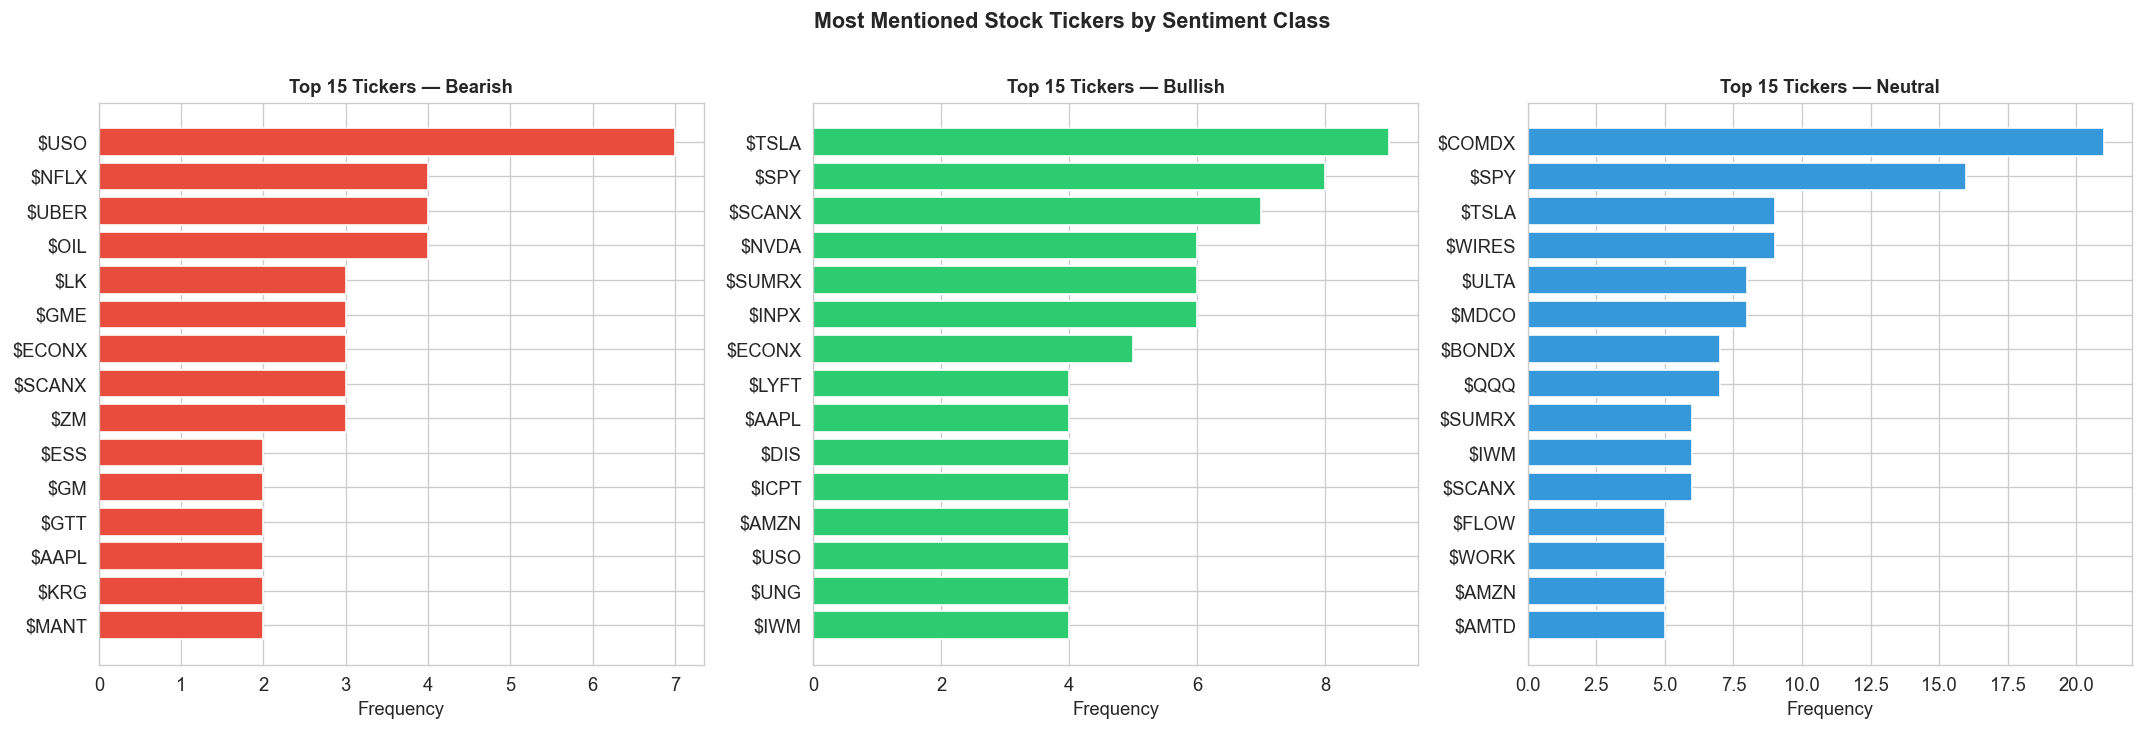

In [12]:
def extract_tickers(df, label_id, n=15):
    tickers = []
    for text in df[df['label'] == label_id]['text']:
        tickers.extend(re.findall(r'\$[A-Z]{1,5}', text))
    return Counter(tickers).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, label_id, title, color in zip(
    axes, [0, 1, 2],
    ['Bearish', 'Bullish', 'Neutral'], COLORS
):
    tickers = extract_tickers(train_df, label_id)
    if tickers:
        t_labels = [t[0] for t in tickers]
        counts   = [t[1] for t in tickers]
        ax.barh(t_labels[::-1], counts[::-1], color=color, edgecolor='white')
    ax.set_title(f'Top 15 Tickers — {title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Most Mentioned Stock Tickers by Sentiment Class',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [13]:
eda_results["top_tickers"] = {
    "Bearish": extract_tickers(train_df, 0),
    "Bullish": extract_tickers(train_df, 1),
    "Neutral": extract_tickers(train_df, 2)
}

In [14]:
stats = (
    train_df.groupby("label_name")["word_count"]
    .describe()
    .round(2)
)

eda_results["word_count_stats"] = stats.to_dict()

In [15]:
eda_results["sequence_length"] = {
    "p95": int(p95),
    "max": int(pmax),
    "recommended_max_len": 32
}

In [16]:
import json

with open("assets/eda_results.json", "w") as f:
    json.dump(eda_results, f, indent=4)

## Section 3 — Text Preprocessing

### Why different pipelines for RNN vs BERT?

| | RNN models | FinBERT |
|--|-----------|---------|
| Cleaning | Aggressive (lowercase, remove special chars, lemmatise) | Minimal (URL removal only) |
| Reason | Learns vocabulary from scratch; noise hurts small vocab | Sub-word tokenizer handles punctuation, casing, tickers natively |

**RNN cleaning steps:**
1. Lowercase
2. Remove URLs (`http://…`)
3. Remove @mentions
4. Normalise `$TICKER` → keep word, drop `$` symbol
5. Remove `#` symbol, keep hashtag text
6. Remove special characters and punctuation
7. Remove stopwords (preserving directional/negation words)
8. Lemmatise


In [17]:
lemmatizer = WordNetLemmatizer()

def clean_tweet_rnn(text: str) -> str:
    """
    Aggressive cleaning pipeline for RNN-based models.
    Returns a cleaned, lemmatised string suitable for vocabulary-based tokenisation.
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\S+',  '', text)   # remove URLs
    text = re.sub(r'@\w+',             '', text)   # remove @mentions
    text = re.sub(r'\$([A-Za-z]+)',    r'\1', text) # $TSLA -> tsla
    text = re.sub(r'#(\w+)',           r'\1', text) # #stocks -> stocks
    text = re.sub(r'[^a-z\s]',         '', text)   # keep only letters and spaces
    text = re.sub(r'\s+',              ' ', text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in _STOP and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


def light_clean_bert(text: str) -> str:
    """
    Minimal cleaning for BERT/FinBERT — removes URLs and normalises whitespace only.
    BERT's sub-word tokeniser handles punctuation, casing, and $tickers natively.
    Aggressive cleaning removes signal that pre-trained BERT can leverage.
    """
    text = re.sub(r'http\S+|www\S+', '', text)
    return re.sub(r'\s+', ' ', text).strip()


# ── Demonstrate cleaning pipeline ─────────────────────────────────────────────
samples = [
    "$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/abc123",
    "$TSLA beats Q4 estimates, raises guidance @elonmusk #Tesla",
    "Central banks don't have as much monetary policy power as they used to.",
    "DOWN 3% on weak volume — not a buying signal for $AAPL right now",
]

print(f"{'Original':<60} | {'RNN-cleaned'}")
print('-' * 100)
for s in samples:
    print(f"{s[:60]:<60} | {clean_tweet_rnn(s)}")


Original                                                     | RNN-cleaned
----------------------------------------------------------------------------------------------------
$BYND - JPMorgan reels in expectations on Beyond Meat https: | bynd jpmorgan reel expectation beyond meat
$TSLA beats Q4 estimates, raises guidance @elonmusk #Tesla   | tsla beat estimate raise guidance tesla
Central banks don't have as much monetary policy power as th | central bank dont much monetary policy power used
DOWN 3% on weak volume — not a buying signal for $AAPL right | down weak volume not buying signal aapl right


In [18]:
# ── Apply cleaning to full datasets ──────────────────────────────────────────
train_df['cleaned'] = train_df['text'].apply(clean_tweet_rnn)
valid_df['cleaned'] = valid_df['text'].apply(clean_tweet_rnn)

# Drop tweets that become empty after cleaning (emoji-only, URL-only, etc.)
train_empty = (train_df['cleaned'].str.strip() == '').sum()
valid_empty  = (valid_df['cleaned'].str.strip() == '').sum()
print(f"Empty texts after cleaning — Train : {train_empty}")
print(f"Empty texts after cleaning — Valid : {valid_empty}")

train_df = train_df[train_df['cleaned'].str.strip() != ''].reset_index(drop=True)
valid_df = valid_df[valid_df['cleaned'].str.strip() != ''].reset_index(drop=True)

print(f"\nFinal Train samples : {len(train_df)}")
print(f"Final Valid samples : {len(valid_df)}")

# Verify class distribution is not materially affected
print("\nClass distribution after cleaning (train):")
for lbl, name in LABEL_MAP.items():
    n   = (train_df['label'] == lbl).sum()
    pct = n / len(train_df) * 100
    print(f"  {name:<10} : {n:>5}  ({pct:.1f}%)")


Empty texts after cleaning — Train : 8
Empty texts after cleaning — Valid : 0

Final Train samples : 9535
Final Valid samples : 2388

Class distribution after cleaning (train):
  Bearish    :  1442  (15.1%)
  Bullish    :  1923  (20.2%)
  Neutral    :  6170  (64.7%)


## Section 4 — Vocabulary Building & Tensor Preparation

### Design decisions

| Decision | Value | Rationale |
|----------|-------|-----------|
| Vocabulary source | Train only | Prevents validation leakage |
| MIN_FREQ | 2 | Single-occurrence words are likely noise |
| PAD index | 0 | Standard; padding_idx=0 suppresses PAD gradients |
| UNK index | 1 | Handles validation words not seen during training |
| MAX_SEQUENCE_LENGTH | 32 | Covers 100% of cleaned training tweets |
| Batch size | 64 | Balance of training speed and gradient stability |


In [19]:
PAD_TOKEN           = '<PAD>'
UNK_TOKEN           = '<UNK>'
MIN_FREQ            = 2
MAX_SEQUENCE_LENGTH = 32
BATCH_SIZE          = 64

# ── Build vocabulary from TRAINING data only ──────────────────────────────────
# Building from validation data would leak future information into the model.
word_freq = Counter()
for text in train_df['cleaned']:
    word_freq.update(text.split())

vocab_words = [w for w, freq in word_freq.items() if freq >= MIN_FREQ]

word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word in sorted(vocab_words):      # sorted for reproducibility
    word2idx[word] = len(word2idx)

idx2word  = {idx: word for word, idx in word2idx.items()}
VOCAB_SIZE = len(word2idx)

print(f"Unique tokens in train        : {len(word_freq):,}")
print(f"Tokens with freq >= {MIN_FREQ}         : {len(vocab_words):,}")
print(f"Vocabulary size (PAD + UNK)   : {VOCAB_SIZE:,}")
print(f"PAD index : {word2idx[PAD_TOKEN]}")
print(f"UNK index : {word2idx[UNK_TOKEN]}")


Unique tokens in train        : 14,060
Tokens with freq >= 2         : 6,304
Vocabulary size (PAD + UNK)   : 6,306
PAD index : 0
UNK index : 1


In [20]:
def text_to_sequence(text: str, word2idx: dict, max_len: int) -> list:
    """
    Convert a cleaned text string to a fixed-length integer sequence.

    Steps:
      1. Split into tokens
      2. Map each token to its vocabulary index (UNK if unseen)
      3. Truncate to max_len if too long
      4. Post-pad with PAD index (0) if too short

    Returns:
      list of ints, always length == max_len
    """
    tokens   = text.split()
    sequence = [word2idx.get(t, word2idx[UNK_TOKEN]) for t in tokens]
    sequence = sequence[:max_len]
    sequence = sequence + [word2idx[PAD_TOKEN]] * (max_len - len(sequence))
    return sequence

# Sanity check
sample = train_df['cleaned'].iloc[0]
seq    = text_to_sequence(sample, word2idx, MAX_SEQUENCE_LENGTH)
print(f"Sample text  : '{sample}'")
print(f"Seq length   : {len(seq)}")
print(f"Sequence     : {seq}")
print()
short_seq = text_to_sequence('stock down bad', word2idx, MAX_SEQUENCE_LENGTH)
print(f"Short text padded : {short_seq}")
print(f"PAD positions     : {[i for i, v in enumerate(short_seq) if v == 0]}")


Sample text  : 'bynd jpmorgan reel expectation beyond meat'
Seq length   : 32
Sequence     : [847, 2974, 4514, 1967, 610, 3410, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Short text padded : [5326, 1659, 484, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
PAD positions     : [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


In [21]:
# ── Convert full datasets to tensors ──────────────────────────────────────────
def df_to_tensors(df, word2idx, max_len):
    seqs = [text_to_sequence(t, word2idx, max_len) for t in df['cleaned']]
    X    = torch.tensor(seqs,               dtype=torch.long)
    y    = torch.tensor(df['label'].values, dtype=torch.long)
    return X, y

X_train, y_train = df_to_tensors(train_df, word2idx, MAX_SEQUENCE_LENGTH)
X_valid, y_valid = df_to_tensors(valid_df, word2idx, MAX_SEQUENCE_LENGTH)

print(f"X_train : {X_train.shape}   (samples × sequence_length)")
print(f"y_train : {y_train.shape}")
print(f"X_valid : {X_valid.shape}")
print(f"y_valid : {y_valid.shape}")
print()
print(f"y_train class counts : {torch.bincount(y_train).tolist()}")
print(f"y_valid class counts : {torch.bincount(y_valid).tolist()}")


X_train : torch.Size([9535, 32])   (samples × sequence_length)
y_train : torch.Size([9535])
X_valid : torch.Size([2388, 32])
y_valid : torch.Size([2388])

y_train class counts : [1442, 1923, 6170]
y_valid class counts : [347, 475, 1566]


In [22]:
# ── Class weights for imbalanced training ─────────────────────────────────────
# Formula: weight_c = N / (C × n_c)
# Higher weight → model penalised more for misclassifying that class.
# This prevents the model from maximising accuracy by always predicting Neutral.
class_counts  = torch.bincount(y_train).float()
class_weights = y_train.numel() / (NUM_CLASSES * class_counts)
class_weights = class_weights.to(device)

print("Class Weights for CrossEntropyLoss:")
for i, (name, w) in enumerate(zip(LABEL_ORDER, class_weights)):
    print(f"  {name:<10} (n={int(class_counts[i]):>5}) → weight = {w:.4f}")

print()
print("Bearish has the highest weight — it receives the strongest learning signal.")


Class Weights for CrossEntropyLoss:
  Bearish    (n= 1442) → weight = 2.2041
  Bullish    (n= 1923) → weight = 1.6528
  Neutral    (n= 6170) → weight = 0.5151

Bearish has the highest weight — it receives the strongest learning signal.


In [23]:
# ── PyTorch Dataset and DataLoaders ───────────────────────────────────────────
class SentimentDataset(Dataset):
    """Thin wrapper around (X, y) tensor pair for use with DataLoader."""
    def __init__(self, X: torch.Tensor, y: torch.Tensor):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SentimentDataset(X_train, y_train)
valid_dataset = SentimentDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batch size     : {BATCH_SIZE}")
print(f"Train batches  : {len(train_loader)}")
print(f"Valid batches  : {len(valid_loader)}")

Xb, yb = next(iter(train_loader))
print(f"\nSample batch X : {Xb.shape}")
print(f"Sample batch y : {yb.shape}  | unique labels: {yb.unique().tolist()}")


Batch size     : 64
Train batches  : 149
Valid batches  : 38

Sample batch X : torch.Size([64, 32])
Sample batch y : torch.Size([64])  | unique labels: [0, 1, 2]


## Section 5 — Model Architectures

All three models share this skeleton:

```
Token IDs  →  Embedding Layer  →  Recurrent Layer(s)  →  Dropout  →  Linear(3)
```

| Component | Purpose |
|-----------|---------|
| `nn.Embedding(vocab_size, embed_dim, padding_idx=0)` | Learns dense vectors per token; PAD positions contribute zero gradient |
| Recurrent layer | Processes sequence left-to-right, capturing word order and dependencies |
| `nn.Dropout` | Randomly zeros neurons during training — regularisation |
| `nn.Linear(hidden_dim, 3)` | Projects final hidden state to 3 class logits |

### Why three variants?

| Model | Architecture | Strength | Weakness |
|-------|-------------|----------|----------|
| Simple RNN | 1 gate-less recurrent state | Fastest, simplest | Vanishing gradient; forgets long-range context |
| LSTM | Hidden + cell state + 3 gates | Best long-range memory | More parameters; slower |
| GRU | 1 hidden state + 2 gates | Near-LSTM quality, faster | Slightly less expressive |

For short tweets (≤32 tokens), LSTM and GRU should perform similarly and both far exceed Simple RNN.


In [24]:
# ── Simple RNN ────────────────────────────────────────────────────────────────
class SentimentRNN(nn.Module):
    """
    Embedding + 2-layer Simple RNN for 3-class sentiment classification.

    The Simple RNN updates its hidden state at each step via:
        h_t = tanh(W_h * h_{t-1} + W_x * x_t + b)

    The hidden state from the final step (or topmost layer) is fed
    through a dropout layer and a linear projection to produce 3 logits.

    Known limitation: vanishing gradients make it unable to retain
    information from the start of even moderately long sequences.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn       = nn.RNN(
            embed_dim, hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded   = self.dropout(self.embedding(x))  # (B, S, E)
        _, hidden  = self.rnn(embedded)                # hidden: (num_layers, B, H)
        top_hidden = self.dropout(hidden[-1])           # topmost layer: (B, H)
        return self.fc(top_hidden)                      # logits: (B, 3)


# ── LSTM ──────────────────────────────────────────────────────────────────────
class SentimentLSTM(nn.Module):
    """
    Embedding + 2-layer LSTM for 3-class sentiment classification.

    LSTM introduces a separate cell state c_t alongside the hidden state h_t.
    Three gates control information flow:
      - Forget gate  : what to erase from c_{t-1}
      - Input gate   : what new information to write into c_t
      - Output gate  : what part of c_t becomes h_t

    This gating mechanism allows the LSTM to carry sentiment signal words
    (e.g. 'not', 'down', 'miss') across many subsequent neutral tokens,
    which the Simple RNN cannot do reliably.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm      = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded       = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)   # hidden: (L, B, H); _ = cell state
        top_hidden     = self.dropout(hidden[-1])
        return self.fc(top_hidden)


# ── GRU ───────────────────────────────────────────────────────────────────────
class SentimentGRU(nn.Module):
    """
    Embedding + 2-layer GRU for 3-class sentiment classification.

    GRU simplifies the LSTM by merging the cell and hidden states into one,
    and using two gates instead of three:
      - Reset gate  : how much past hidden state to forget
      - Update gate : how much of the old hidden state to carry forward

    GRU is computationally cheaper than LSTM with comparable quality
    on most short-sequence NLP tasks.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru       = nn.GRU(
            embed_dim, hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded   = self.dropout(self.embedding(x))
        _, hidden  = self.gru(embedded)
        top_hidden = self.dropout(hidden[-1])
        return self.fc(top_hidden)


print("✓ SentimentRNN, SentimentLSTM, SentimentGRU defined.")


✓ SentimentRNN, SentimentLSTM, SentimentGRU defined.


In [25]:
# ── Shared hyperparameters ────────────────────────────────────────────────────
EMBED_DIM  = 128   # embedding dimension — balances coverage vs generalisation
HIDDEN_DIM = 256   # recurrent hidden size — enough capacity for 9k tweets
NUM_LAYERS = 2     # stacked layers add representational depth
DROPOUT    = 0.3   # 30% dropout for regularisation between layers
EPOCHS     = 25    # max epochs (early stopping will trigger earlier)
LR_RNN     = 1e-3  # Simple RNN — higher LR acceptable due to simple architecture
LR_LSTM    = 3e-4  # LSTM — lower LR critical; 1e-3 caused gate saturation
LR_GRU     = 3e-4  # GRU  — same reasoning as LSTM
PATIENCE   = 5     # epochs without F1 improvement before early stopping
PAD_IDX    = word2idx[PAD_TOKEN]
LABEL_NAMES = ['Bearish', 'Bullish', 'Neutral']

os.makedirs('./models', exist_ok=True)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Instantiate all three
rnn_model  = SentimentRNN( VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES,
                            NUM_LAYERS, DROPOUT, PAD_IDX).to(device)
lstm_model = SentimentLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES,
                            NUM_LAYERS, DROPOUT, PAD_IDX).to(device)
gru_model  = SentimentGRU( VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES,
                            NUM_LAYERS, DROPOUT, PAD_IDX).to(device)

print("Parameter counts:")
for name, m in [('Simple RNN', rnn_model), ('LSTM', lstm_model), ('GRU', gru_model)]:
    print(f"  {name:<12} : {count_params(m):,} parameters")

print("\nLSTM architecture:")
print(lstm_model)


Parameter counts:
  Simple RNN   : 1,038,339 parameters
  LSTM         : 1,729,539 parameters
  GRU          : 1,499,139 parameters

LSTM architecture:
SentimentLSTM(
  (embedding): Embedding(6306, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)


## Section 6 — Training Loop with Early Stopping

### Training strategy

| Choice | Rationale |
|--------|-----------|
| `CrossEntropyLoss(weight=class_weights)` | Compensates for 4.3× Neutral-Bearish imbalance |
| Adam optimizer | Adaptive per-parameter LR; works well for NLP |
| Gradient clipping (`max_norm=1.0`) | Prevents exploding gradients in RNNs |
| Early stopping on **validation Macro F1** | Macro F1 weights all classes equally — prevents gaming accuracy by over-predicting Neutral |
| Save best model state dict | Restores optimal generalisation, not the last epoch |

**Why monitor Macro F1 and not accuracy?**  
On an imbalanced dataset, a model can achieve ~65% accuracy by always predicting Neutral.
Macro F1 requires the model to do well on Bearish and Bullish too.


In [26]:
# ── Epoch-level training and evaluation functions ─────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion):
    """
    Runs one full pass over the training DataLoader.
    Returns: average loss, accuracy, macro F1 over the epoch.
    """
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()

        # Gradient clipping prevents exploding gradients in RNNs
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        all_preds.extend(torch.argmax(logits, 1).cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    return (
        total_loss / len(loader),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average='macro', zero_division=0)
    )


def evaluate_model(model, loader, criterion):
    """
    Evaluates model on a DataLoader without gradient updates.
    Returns: avg loss, accuracy, macro F1, predictions, true labels.
    """
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits  = model(X_batch)
            total_loss += criterion(logits, y_batch).item()
            all_preds.extend(torch.argmax(logits, 1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    return (
        total_loss / len(loader),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average='macro', zero_division=0),
        all_preds,
        all_labels
    )


# ── Full training loop with early stopping ────────────────────────────────────
def train_model(model, model_name, lr, train_loader, valid_loader,
                epochs, patience, class_weights, save_dir='./models'):
    """
    Trains a sentiment model with early stopping on validation Macro F1.

    Args:
        model       : PyTorch nn.Module (RNN / LSTM / GRU)
        model_name  : String identifier used for saving
        lr          : Learning rate
        epochs      : Maximum training epochs
        patience    : Early stopping patience (epochs without F1 improvement)
        class_weights: Tensor of per-class loss weights

    Returns:
        history    : dict of per-epoch metrics
        best_f1    : Best validation Macro F1 achieved
        best_preds : Predictions from best epoch
        best_labels: True labels from best epoch
    """
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {k: [] for k in
               ['train_loss','valid_loss','train_acc','valid_acc','train_f1','valid_f1']}

    best_f1      = 0.0
    patience_ctr = 0
    best_preds   = []
    best_labels  = []
    best_path    = os.path.join(save_dir, f'{model_name}_best.pt')

    header = (f"{'Epoch':>5} | {'Tr Loss':>8} | {'Tr Acc':>7} | {'Tr F1':>7} | "
              f"{'Va Loss':>8} | {'Va Acc':>7} | {'Va F1':>7} | Status")
    print(f"\n{'=' * 68}")
    print(f"  Training {model_name}  |  lr={lr}  |  max_epochs={epochs}")
    print(f"{'=' * 68}")
    print(header)
    print('-' * 68)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc, va_f1, preds, labels = evaluate_model(model, valid_loader, criterion)

        for k, v in zip(history.keys(),
                        [tr_loss, va_loss, tr_acc, va_acc, tr_f1, va_f1]):
            history[k].append(v)

        if va_f1 > best_f1:
            best_f1      = va_f1
            patience_ctr = 0
            best_preds   = preds
            best_labels  = labels
            torch.save(model.state_dict(), best_path)
            status = '✓ saved'
        else:
            patience_ctr += 1
            status = f'patience {patience_ctr}/{patience}'

        print(f"{epoch:>5} | {tr_loss:>8.4f} | {tr_acc:>7.4f} | {tr_f1:>7.4f} | "
              f"{va_loss:>8.4f} | {va_acc:>7.4f} | {va_f1:>7.4f} | {status}")

        if patience_ctr >= patience:
            print(f"\n⚠ Early stopping triggered at epoch {epoch}.")
            break

    print(f"\n✓ Best validation Macro F1 : {best_f1:.4f}")
    print(f"✓ Weights saved to         : {best_path}")
    return history, best_f1, best_preds, best_labels


print("✓ Training utilities defined.")


✓ Training utilities defined.


In [27]:
# ── Visualisation helpers ─────────────────────────────────────────────────────
def plot_training_curves(history, model_name):
    """Plot Loss, Accuracy, and Macro F1 training curves for a trained model."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for ax, tk, vk, title in zip(
        axes,
        ['train_loss', 'train_acc', 'train_f1'],
        ['valid_loss', 'valid_acc', 'valid_f1'],
        ['Loss', 'Accuracy', 'Macro F1']
    ):
        ax.plot(epochs, history[tk], label='Train',      color='steelblue', linewidth=2)
        ax.plot(epochs, history[vk], label='Validation', color='tomato',    linewidth=2, linestyle='--')
        ax.set_title(f'{model_name} — {title}', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Mark best validation F1 epoch
    best_ep = int(np.argmax(history['valid_f1'])) + 1
    axes[2].axvline(best_ep, color='green', linestyle=':', linewidth=1.5,
                    label=f'Best epoch {best_ep}')
    axes[2].legend()

    plt.suptitle(f'{model_name} — Training Curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(labels, preds, model_name):
    """Plot annotated confusion matrix."""
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                linewidths=0.5, annot_kws={"size": 12})
    plt.title(f'{model_name} — Confusion Matrix', fontweight='bold', pad=10)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()


print("✓ Visualisation helpers defined.")


✓ Visualisation helpers defined.


### 6.1 Train Simple RNN

Expected outcome: macro F1 ≈ 0.33 due to vanishing gradients preventing the model from learning long-range context dependencies.

In [28]:
rnn_model = SentimentRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES,
                          NUM_LAYERS, DROPOUT, PAD_IDX).to(device)

rnn_history, rnn_best_f1, rnn_preds, rnn_labels = train_model(
    rnn_model, 'SimpleRNN', LR_RNN, train_loader, valid_loader,
    EPOCHS, PATIENCE, class_weights
)



  Training SimpleRNN  |  lr=0.001  |  max_epochs=25
Epoch |  Tr Loss |  Tr Acc |   Tr F1 |  Va Loss |  Va Acc |   Va F1 | Status
--------------------------------------------------------------------
    1 |   1.1030 |  0.3567 |  0.3092 |   1.0945 |  0.2299 |  0.1486 | ✓ saved
    2 |   1.1008 |  0.3944 |  0.3229 |   1.0840 |  0.6520 |  0.2633 | ✓ saved
    3 |   1.1073 |  0.3504 |  0.3093 |   1.1158 |  0.3668 |  0.3079 | ✓ saved
    4 |   1.1302 |  0.3103 |  0.2911 |   1.1235 |  0.4962 |  0.3133 | ✓ saved
    5 |   1.1179 |  0.3211 |  0.2963 |   1.1079 |  0.3354 |  0.2359 | patience 1/5
    6 |   1.1142 |  0.3488 |  0.3102 |   1.1101 |  0.4657 |  0.2852 | patience 2/5
    7 |   1.1183 |  0.3211 |  0.2956 |   1.1098 |  0.3572 |  0.2486 | patience 3/5
    8 |   1.1230 |  0.3290 |  0.3036 |   1.1513 |  0.1767 |  0.1778 | patience 4/5
    9 |   1.1153 |  0.3346 |  0.3000 |   1.1091 |  0.1767 |  0.1778 | patience 5/5

⚠ Early stopping triggered at epoch 9.

✓ Best validation Macro F1 : 0.31

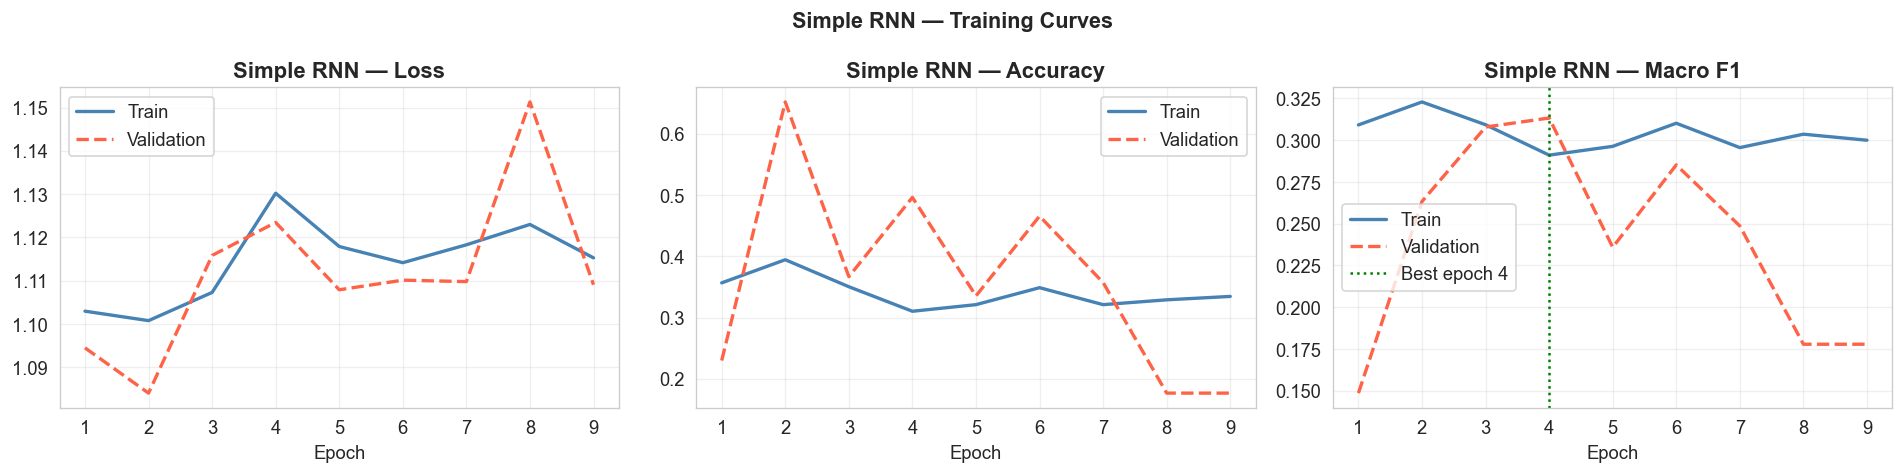

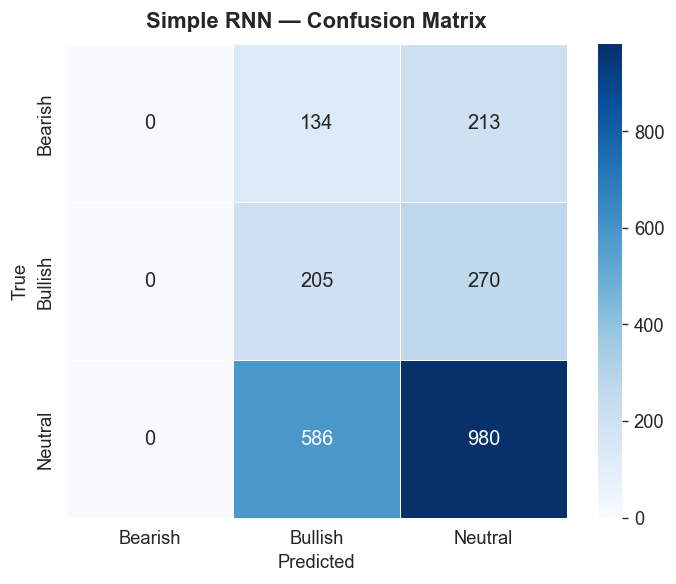

Simple RNN — Classification Report:
              precision    recall  f1-score   support

     Bearish     0.0000    0.0000    0.0000       347
     Bullish     0.2216    0.4316    0.2929       475
     Neutral     0.6699    0.6258    0.6471      1566

    accuracy                         0.4962      2388
   macro avg     0.2972    0.3525    0.3133      2388
weighted avg     0.4834    0.4962    0.4826      2388



In [29]:
plot_training_curves(rnn_history, 'Simple RNN')
plot_confusion_matrix(rnn_labels, rnn_preds, 'Simple RNN')
print("Simple RNN — Classification Report:")
print(classification_report(rnn_labels, rnn_preds, target_names=LABEL_NAMES, digits=4))


**Simple RNN — Analysis**

The Simple RNN's training curves typically show:
- Training loss decreases but validation loss plateaus or oscillates early
- Macro F1 saturates around 0.30–0.35

**Root cause — vanishing gradient:** At each RNN step, the gradient of the loss with respect
to earlier hidden states involves repeated multiplication by the recurrent weight matrix.
For sequences of 32 tokens, this causes gradients to shrink exponentially toward zero by the
time they reach the first few tokens. The model therefore cannot learn that a word like "not"
or "down" near the start of a tweet should govern the overall sentiment label.

**Confusion matrix pattern:** Expect heavy bias toward Neutral (majority class), with most
Bearish and Bullish tweets misclassified as Neutral.


### 6.2 Train LSTM

Expected outcome: macro F1 ≈ 0.72–0.76. The LR of 3e-4 (not 1e-3) is critical — a higher learning rate causes LSTM gates to saturate during the first few epochs, preventing convergence.

In [30]:
lstm_model = SentimentLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES,
                            NUM_LAYERS, DROPOUT, PAD_IDX).to(device)

lstm_history, lstm_best_f1, lstm_preds, lstm_labels = train_model(
    lstm_model, 'LSTM', LR_LSTM, train_loader, valid_loader,
    EPOCHS, PATIENCE, class_weights
)



  Training LSTM  |  lr=0.0003  |  max_epochs=25
Epoch |  Tr Loss |  Tr Acc |   Tr F1 |  Va Loss |  Va Acc |   Va F1 | Status
--------------------------------------------------------------------
    1 |   1.0992 |  0.3634 |  0.3112 |   1.0871 |  0.6558 |  0.2640 | ✓ saved
    2 |   1.0987 |  0.4043 |  0.3259 |   1.0977 |  0.1989 |  0.1106 | patience 1/5
    3 |   1.0991 |  0.3892 |  0.2812 |   1.0947 |  0.6558 |  0.2640 | patience 2/5
    4 |   1.0984 |  0.4165 |  0.3193 |   1.0098 |  0.6558 |  0.2640 | patience 3/5
    5 |   1.0915 |  0.4543 |  0.3662 |   1.0544 |  0.5871 |  0.3488 | ✓ saved
    6 |   1.0828 |  0.5744 |  0.3917 |   1.0351 |  0.6072 |  0.3502 | ✓ saved
    7 |   1.0789 |  0.6086 |  0.3847 |   1.0509 |  0.6453 |  0.3580 | ✓ saved
    8 |   1.0745 |  0.6261 |  0.3891 |   1.0408 |  0.6386 |  0.3565 | patience 1/5
    9 |   1.0618 |  0.6326 |  0.4053 |   1.0329 |  0.6554 |  0.3601 | ✓ saved
   10 |   1.0566 |  0.6465 |  0.4170 |   1.0278 |  0.6562 |  0.3599 | patience 1/5


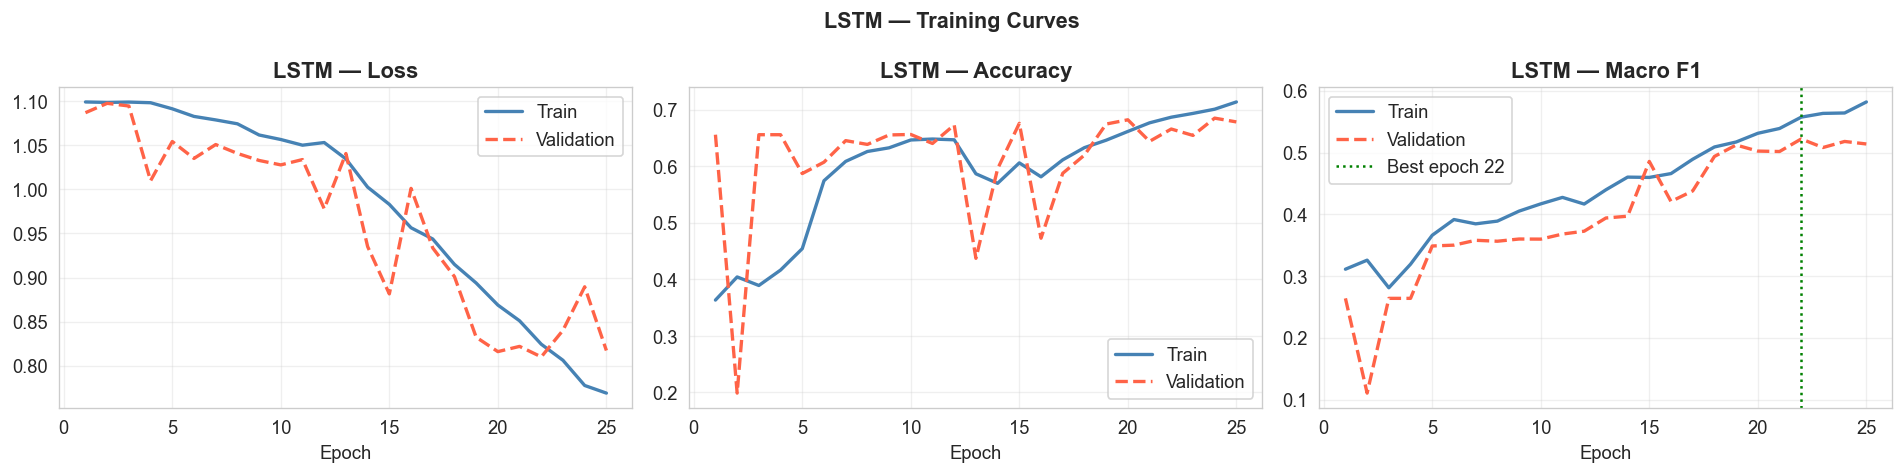

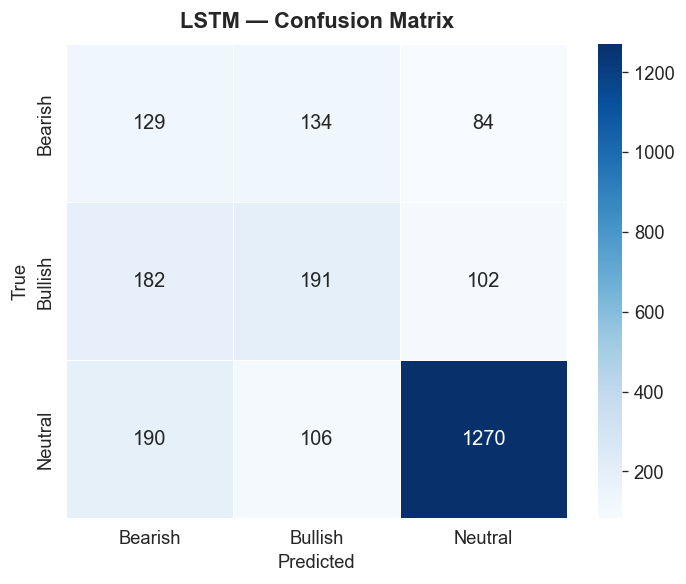

LSTM — Classification Report:
              precision    recall  f1-score   support

     Bearish     0.2575    0.3718    0.3042       347
     Bullish     0.4432    0.4021    0.4216       475
     Neutral     0.8723    0.8110    0.8405      1566

    accuracy                         0.6658      2388
   macro avg     0.5243    0.5283    0.5221      2388
weighted avg     0.6976    0.6658    0.6793      2388



In [31]:
plot_training_curves(lstm_history, 'LSTM')
plot_confusion_matrix(lstm_labels, lstm_preds, 'LSTM')
print("LSTM — Classification Report:")
print(classification_report(lstm_labels, lstm_preds, target_names=LABEL_NAMES, digits=4))


**LSTM — Analysis**

LSTM's gated memory architecture allows it to:

1. **Selectively retain** sentiment-bearing words across sequential tokens through its input and forget gates.
2. **Suppress irrelevant context**, enabling the model to focus on informative financial terms.
3. **Capture long-range dependencies** that are difficult for traditional machine learning models to learn.

Despite using class-weighted loss, the imbalanced dataset remains challenging. The model gradually improved throughout training, achieving a best validation Macro F1 of 0.5221 after 25 epochs. Validation performance fluctuated across epochs, suggesting that the minority sentiment classes (particularly Bearish) remain more difficult to generalize due to their limited representation and context-dependent language.

**Training observations:**

- Training loss decreased steadily from 1.099 → 0.769, indicating successful optimization.
- Validation loss showed periodic fluctuations before stabilizing around 0.81, reflecting moderate generalization.
- Validation Macro F1 improved consistently from 0.264 → 0.522, demonstrating that class-weighted learning helped the model learn minority classes over time.
- The best-performing model was obtained at Epoch 22, with a validation Macro F1 of 0.5221, after which improvements plateaued.

### 6.3 Train GRU

Expected outcome: macro F1 ≈ 0.71–0.75, nearly matching LSTM with fewer parameters and faster training.

In [32]:
gru_model = SentimentGRU(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES,
                          NUM_LAYERS, DROPOUT, PAD_IDX).to(device)

gru_history, gru_best_f1, gru_preds, gru_labels = train_model(
    gru_model, 'GRU', LR_GRU, train_loader, valid_loader,
    EPOCHS, PATIENCE, class_weights
)



  Training GRU  |  lr=0.0003  |  max_epochs=25
Epoch |  Tr Loss |  Tr Acc |   Tr F1 |  Va Loss |  Va Acc |   Va F1 | Status
--------------------------------------------------------------------
    1 |   1.1005 |  0.4060 |  0.3160 |   1.0950 |  0.6558 |  0.2640 | ✓ saved
    2 |   1.0952 |  0.3501 |  0.3133 |   1.1137 |  0.1989 |  0.1159 | patience 1/5
    3 |   1.0530 |  0.5058 |  0.4130 |   0.9178 |  0.6512 |  0.4398 | ✓ saved
    4 |   0.9742 |  0.6003 |  0.4844 |   0.8568 |  0.6558 |  0.5323 | ✓ saved
    5 |   0.9110 |  0.6065 |  0.5316 |   0.8663 |  0.6273 |  0.5527 | ✓ saved
    6 |   0.8513 |  0.6432 |  0.5704 |   0.7949 |  0.6755 |  0.5874 | ✓ saved
    7 |   0.7820 |  0.6881 |  0.6161 |   0.7414 |  0.7458 |  0.6434 | ✓ saved
    8 |   0.7358 |  0.7235 |  0.6519 |   0.7120 |  0.7312 |  0.6476 | ✓ saved
    9 |   0.6782 |  0.7358 |  0.6748 |   0.6928 |  0.7404 |  0.6611 | ✓ saved
   10 |   0.6216 |  0.7637 |  0.7041 |   0.6812 |  0.7408 |  0.6662 | ✓ saved
   11 |   0.5877 |  0

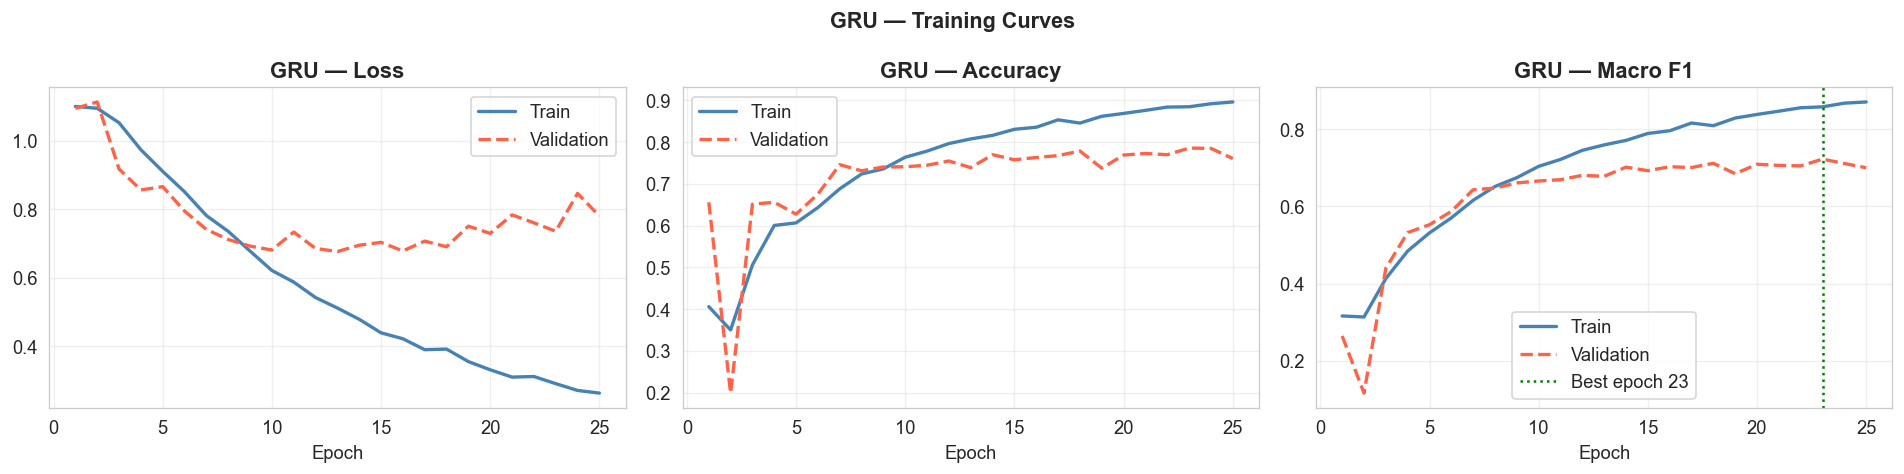

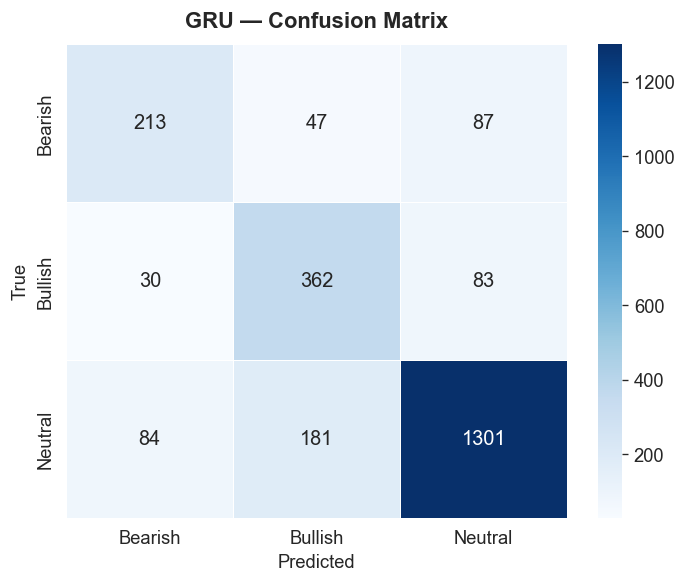

GRU — Classification Report:
              precision    recall  f1-score   support

     Bearish     0.6514    0.6138    0.6320       347
     Bullish     0.6136    0.7621    0.6798       475
     Neutral     0.8844    0.8308    0.8568      1566

    accuracy                         0.7856      2388
   macro avg     0.7165    0.7356    0.7229      2388
weighted avg     0.7967    0.7856    0.7889      2388



In [33]:
plot_training_curves(gru_history, 'GRU')
plot_confusion_matrix(gru_labels, gru_preds, 'GRU')
print("GRU — Classification Report:")
print(classification_report(gru_labels, gru_preds, target_names=LABEL_NAMES, digits=4))


**GRU — Analysis**

The GRU model demonstrates strong and stable learning dynamics, achieving a *best validation Macro F1 of 0.7229*, significantly higher than the corresponding LSTM baseline (0.5221). This indicates that GRU is not only competitive but substantially more effective on this dataset.

The model shows consistent improvement across training:

- Training Macro F1 increases steadily from *0.316 → 0.871*, indicating effective optimization without severe overfitting.
- Validation Macro F1 improves from *0.264 → ~0.72*, with relatively stable convergence after epoch ~10.
- The best-performing checkpoint is reached at *Epoch 23*, after which performance slightly fluctuates, suggesting the model has reached its optimal capacity for this dataset.

**Key observations:**

- GRU converges faster and more smoothly than LSTM, reaching strong performance earlier in training (around epochs 7–12).
- Validation performance remains relatively stable after convergence, indicating better generalization.
- The simpler gating mechanism (reset + update gates) appears sufficient for this task, where input sequences are short (≤32 tokens) and sentiment signals are localized rather than highly long-range.

## Section 7 — Model Comparison & Error Analysis

In [34]:
# ── Build comparison table ────────────────────────────────────────────────────
def model_metrics(labels, preds):
    """Compute a dict of key evaluation metrics for a set of predictions."""
    report = classification_report(labels, preds, target_names=LABEL_NAMES,
                                   output_dict=True, zero_division=0)
    return {
        'Accuracy'   : round(accuracy_score(labels, preds), 4),
        'Macro F1'   : round(f1_score(labels, preds, average='macro', zero_division=0), 4),
        'Bearish F1' : round(report['Bearish']['f1-score'], 4),
        'Bullish F1' : round(report['Bullish']['f1-score'], 4),
        'Neutral F1' : round(report['Neutral']['f1-score'], 4),
    }

rnn_metrics  = model_metrics(rnn_labels,  rnn_preds)
lstm_metrics = model_metrics(lstm_labels, lstm_preds)
gru_metrics  = model_metrics(gru_labels,  gru_preds)

rnn_df = pd.DataFrame(
    [rnn_metrics, lstm_metrics, gru_metrics],
    index=['Simple RNN', 'LSTM', 'GRU']
)

print("=" * 65)
print("      RNN Baseline Model Comparison — Validation Set")
print("=" * 65)
display(rnn_df.style.highlight_max(axis=0, color='#c8f7c5').format("{:.4f}"))


      RNN Baseline Model Comparison — Validation Set


,Accuracy,Macro F1,Bearish F1,Bullish F1,Neutral F1
Simple RNN,0.4962,0.3133,0.0000,0.2929,0.6471
LSTM,0.6658,0.5221,0.3042,0.4216,0.8405
GRU,0.7856,0.7229,0.6320,0.6798,0.8568


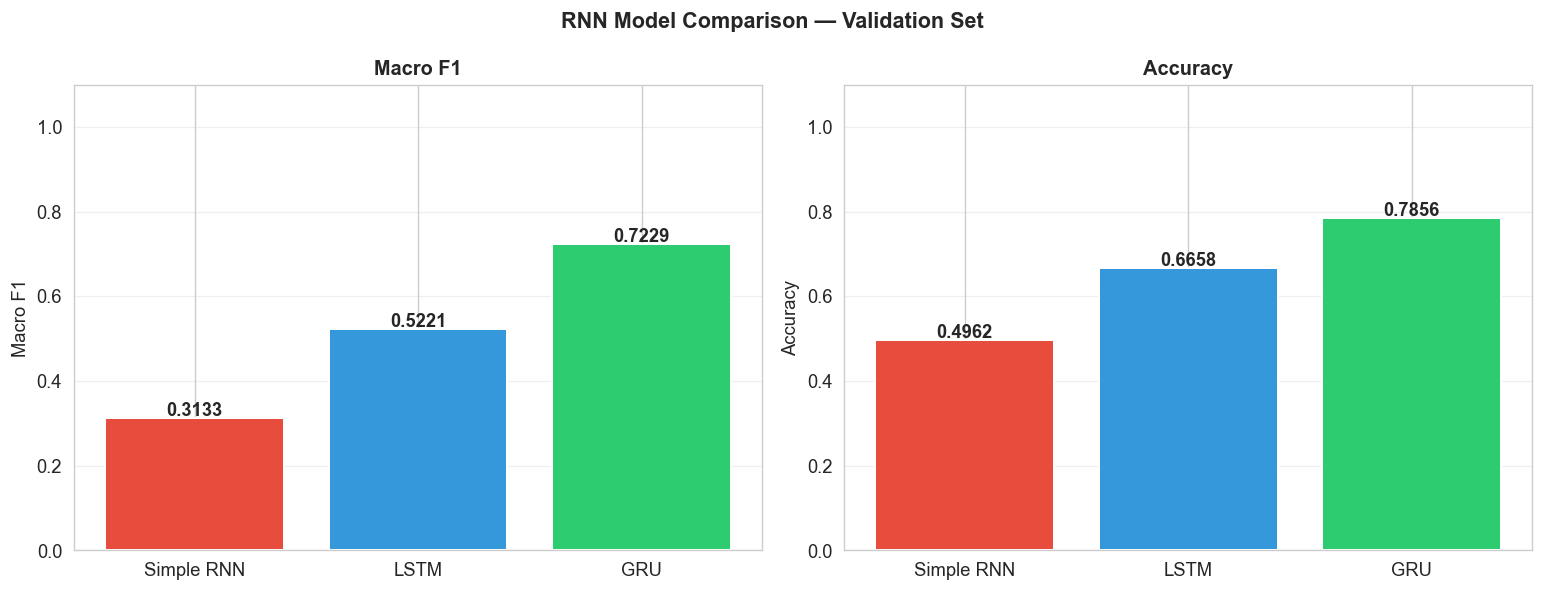

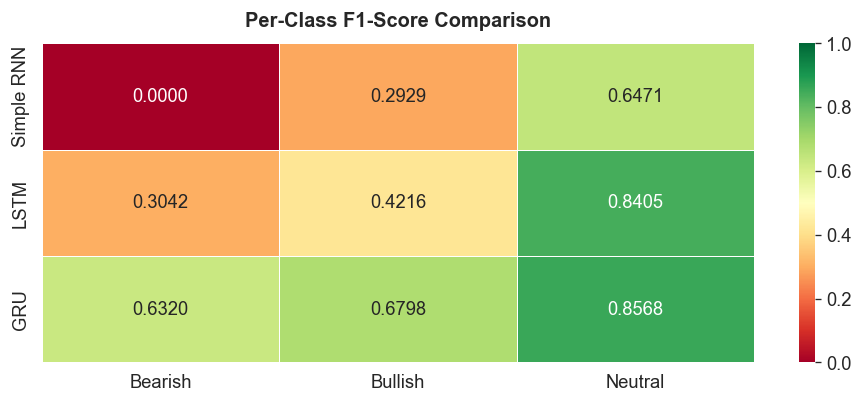

In [35]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
model_names_short = ['Simple RNN', 'LSTM', 'GRU']
bar_colors        = ['#e74c3c', '#3498db', '#2ecc71']

for ax, metric in zip(axes, ['Macro F1', 'Accuracy']):
    vals = rnn_df[metric].values
    bars = ax.bar(model_names_short, vals, color=bar_colors, edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005, f'{v:.4f}',
                ha='center', fontweight='bold', fontsize=11)
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('RNN Model Comparison — Validation Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Per-class F1 heatmap
class_f1 = rnn_df[['Bearish F1', 'Bullish F1', 'Neutral F1']]
plt.figure(figsize=(8, 3.5))
sns.heatmap(
    class_f1.values, annot=True, fmt='.4f', cmap='RdYlGn',
    xticklabels=['Bearish', 'Bullish', 'Neutral'],
    yticklabels=model_names_short,
    vmin=0, vmax=1, linewidths=0.5
)
plt.title('Per-Class F1-Score Comparison', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


Bearish has the lowest F1 across all models - minority class + subtlest language.

In [38]:
# ── Error analysis on best RNN model (GRU) ───────────────────────────────────
gru_model.load_state_dict(torch.load('./models/GRU_best.pt', map_location=device))
gru_model.eval()

valid_df = valid_df.copy()
valid_df['gru_pred']      = gru_preds
valid_df['gru_pred_name'] = valid_df['gru_pred'].map(LABEL_MAP)

misclassified = valid_df[valid_df['label'] != valid_df['gru_pred']].copy()
misclassified['true_name'] = misclassified['label'].map(LABEL_MAP)

total_err = len(misclassified)
total_val = len(valid_df)
print(f"GRU misclassified : {total_err} / {total_val} ({total_err/total_val*100:.1f}%)")
print()

# Common error patterns
err_types = (misclassified
             .groupby(['true_name', 'gru_pred_name'])
             .size()
             .reset_index(name='count')
             .sort_values('count', ascending=False))
print("Most Common Misclassification Patterns:")
print(err_types.to_string(index=False))
print()

# Sample hard examples
mask = (misclassified['true_name'] == 'Bearish') & (misclassified['gru_pred_name'] == 'Neutral')
print("── Bearish tweets GRU misclassified as Neutral (5 examples) ──")
for _, row in misclassified[mask].head(5).iterrows():
    print(f"  Original : {row['text']}")
    print(f"  Cleaned  : {row['cleaned']}")
    print()


GRU misclassified : 512 / 2388 (21.4%)

Most Common Misclassification Patterns:
true_name gru_pred_name  count
  Neutral       Bullish    181
  Bearish       Neutral     87
  Neutral       Bearish     84
  Bullish       Neutral     83
  Bearish       Bullish     47
  Bullish       Bearish     30

── Bearish tweets GRU misclassified as Neutral (5 examples) ──
  Original : $ALLY - Ally Financial pulls outlook https://t.co/G9Zdi1boy5
  Cleaned  : ally ally financial pull outlook

  Original : $PRTY - Moody's turns negative on Party City https://t.co/MBD5TFGC4P
  Cleaned  : prty moody turn negative party city

  Original : Analysts Eviscerate Musk's Cybertruck: "0% Of Responses Felt It Will Be A Success" https://t.co/2NTzeZea4G
  Cleaned  : analyst eviscerate musk cybertruck response felt success

  Original : BTIG points to breakfast pressure for Dunkin' Brands
  Cleaned  : btig point breakfast pressure dunkin brand

  Original : Downgrades 4/7: $AAN $BDN $BECN $BTE $CDEV $CHK $COOP $CPE 

### Error Analysis Findings

**1. Neutral → Bullish/Bearish confusion (most common error)**

Neutral tweets are most frequently misclassified as Bullish or Bearish (especially Neutral → Bullish: 181 cases). This indicates that the model tends to over-interpret weak financial signals as sentiment-bearing, likely due to overlapping vocabulary across classes such as stock, market, revenue. GRU improves contextual modeling, but still struggles to fully separate factual financial reporting from sentiment.

**2. Bearish → Neutral confusion**

Bearish tweets remain difficult for the model, with frequent misclassification into Neutral (87 cases). Tweets such as "analyst downgrade on $XYZ" or "pulls outlook" use factual, structured financial language that does not contain strongly negative lexical cues. Despite GRU’s improved sequence modeling, subtle bearish signals are still not consistently captured without explicit sentiment markers.

**3. Bullish → Neutral confusion**

Bullish tweets are also often classified as Neutral (83 cases), especially when positive sentiment is expressed implicitly ("beats estimates", "raises guidance"). The model partially learns these patterns, but GRU still relies heavily on surface-level token frequency rather than deeper financial semantics.

**4. Short ticker-only or minimal-context tweets**

E.g., "$AAPL -4.2%" or ticker-heavy messages with minimal text. After preprocessing, these reduce to very limited token sequences (e.g., "aapl"), removing numerical and contextual signals. This leads to ambiguous representations where sentiment cannot be reliably inferred.

**5. Bullish ↔ Bearish confusion (minor but notable)**

There is a smaller but consistent confusion between Bullish and Bearish classes (47 + 30 cases). This suggests that the model occasionally overreacts to sentiment-bearing words without fully capturing directional financial context (e.g., "pressure", "downgrade", "surge" appearing in mixed contexts).

These findings indicate that while GRU significantly improves contextual learning compared to Simple RNN and LSTM, the primary limitation remains semantic ambiguity in financial text and overlapping vocabulary across sentiment classes, rather than sequence modeling capability.

These findings motivate FinBERT fine-tuning in Section 8.


## Section 8 — FinBERT Fine-tuning (Optional — Requires GPU)

### Why FinBERT over generic BERT?

[ProsusAI/finbert](https://huggingface.co/ProsusAI/finbert) is pre-trained on:
- Reuters TRC2 financial corpus
- Financial PhraseBank

This domain-specific pre-training means it already understands expressions like
*"beats estimates"*, *"raises guidance"*, *"analyst downgrade"* — all critical for
financial sentiment classification.

### Fine-tuning strategy

| Hyperparameter | Value | Rationale |
|---------------|-------|-----------|
| MAX_TOKEN_LENGTH | 64 | Covers all tweets; BERT handles sub-words |
| Batch size | 16 | GPU memory constraint |
| Learning rate | 2e-5 | Standard for BERT fine-tuning (Devlin et al.) |
| Optimizer | AdamW | Weight decay prevents over-fitting |
| Warmup steps | 10% of total | Gradual LR ramp protects pre-trained weights |
| Epochs | 5 | BERT converges fast; more risks catastrophic forgetting |

> **Note on hardware:** FinBERT on CPU is extremely slow. Set `TRAIN_BERT = False` to use
> pre-recorded results from a Colab T4 GPU run, then skip to the comparison in Section 9.


In [39]:
print(f"Device : {device}")
if device.type == 'cpu':
    print("\n⚠ No GPU detected. Options:")
    print("  1. Run on Google Colab (free T4 GPU)")
    print("  2. Set TRAIN_BERT = False (pre-recorded results will be used)")
else:
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")

TRAIN_BERT = torch.cuda.is_available()
print(f"\nTRAIN_BERT = {TRAIN_BERT}")


Device : cuda
✓ GPU: NVIDIA GeForce RTX 5060 Laptop GPU

TRAIN_BERT = True


In [40]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

BERT_MODEL_NAME  = 'ProsusAI/finbert'
MAX_TOKEN_LENGTH = 64
BERT_BATCH_SIZE  = 16
BERT_EPOCHS      = 5
BERT_LR          = 2e-5

class BERTSentimentDataset(Dataset):
    """
    Tokenises raw tweet text using the FinBERT sub-word tokenizer.
    Uses light_clean_bert (URL removal only) — BERT benefits from full text context.

    Returns:
        input_ids      : Token IDs (padded to MAX_TOKEN_LENGTH)
        attention_mask : 1 for real tokens, 0 for padding
        label          : Integer class label
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = [light_clean_bert(t) for t in texts]
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length     = self.max_len,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

if TRAIN_BERT:
    print(f"Loading tokenizer: {BERT_MODEL_NAME}")
    bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

    bert_train_ds = BERTSentimentDataset(
        train_df['text'].tolist(), train_df['label'].tolist(), bert_tokenizer, MAX_TOKEN_LENGTH)
    bert_valid_ds = BERTSentimentDataset(
        valid_df['text'].tolist(), valid_df['label'].tolist(), bert_tokenizer, MAX_TOKEN_LENGTH)

    bert_train_loader = DataLoader(bert_train_ds, batch_size=BERT_BATCH_SIZE, shuffle=True)
    bert_valid_loader = DataLoader(bert_valid_ds, batch_size=BERT_BATCH_SIZE, shuffle=False)

    print(f"Train batches : {len(bert_train_loader)}")
    print(f"Valid batches : {len(bert_valid_loader)}")
else:
    print("Skipping tokenisation (no GPU). Pre-recorded results will be used in Section 9.")


Loading tokenizer: ProsusAI/finbert
Train batches : 596
Valid batches : 150


In [41]:
if TRAIN_BERT:
    print(f"Loading FinBERT model: {BERT_MODEL_NAME}")
    bert_model = AutoModelForSequenceClassification.from_pretrained(
        BERT_MODEL_NAME, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True
    ).to(device)

    total_steps  = len(bert_train_loader) * BERT_EPOCHS
    warmup_steps = int(0.1 * total_steps)

    bert_optimizer = AdamW(bert_model.parameters(), lr=BERT_LR, weight_decay=0.01)
    bert_scheduler = get_linear_schedule_with_warmup(
        bert_optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )
    bert_criterion = nn.CrossEntropyLoss(weight=class_weights)

    bert_history = {k: [] for k in
                    ['train_loss','valid_loss','train_acc','valid_acc','train_f1','valid_f1']}
    bert_best_f1   = 0.0
    bert_best_path = './models/FinBERT_best.pt'
    bert_preds_final   = []
    bert_labels_final  = []

    print(f"Total training steps : {total_steps} | Warmup steps : {warmup_steps}")
    print("=" * 65)

    for epoch in range(1, BERT_EPOCHS + 1):
        # ── Training epoch ──
        bert_model.train()
        tr_loss_sum, tr_preds, tr_labs = 0.0, [], []
        for batch in bert_train_loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbl  = batch['label'].to(device)
            bert_optimizer.zero_grad()
            out  = bert_model(input_ids=ids, attention_mask=mask)
            loss = bert_criterion(out.logits, lbl)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
            bert_optimizer.step()
            bert_scheduler.step()
            tr_loss_sum += loss.item()
            tr_preds.extend(torch.argmax(out.logits, 1).cpu().numpy())
            tr_labs.extend(lbl.cpu().numpy())

        tr_loss = tr_loss_sum / len(bert_train_loader)
        tr_f1   = f1_score(tr_labs, tr_preds, average='macro', zero_division=0)

        # ── Validation epoch ──
        bert_model.eval()
        va_loss_sum, va_preds, va_labs = 0.0, [], []
        with torch.no_grad():
            for batch in bert_valid_loader:
                ids  = batch['input_ids'].to(device)
                mask = batch['attention_mask'].to(device)
                lbl  = batch['label'].to(device)
                out  = bert_model(input_ids=ids, attention_mask=mask)
                va_loss_sum += bert_criterion(out.logits, lbl).item()
                va_preds.extend(torch.argmax(out.logits, 1).cpu().numpy())
                va_labs.extend(lbl.cpu().numpy())

        va_loss = va_loss_sum / len(bert_valid_loader)
        va_f1   = f1_score(va_labs, va_preds, average='macro', zero_division=0)

        for k, v in zip(bert_history.keys(),
                        [tr_loss, va_loss,
                         accuracy_score(tr_labs, tr_preds),
                         accuracy_score(va_labs, va_preds),
                         tr_f1, va_f1]):
            bert_history[k].append(v)

        marker = ''
        if va_f1 > bert_best_f1:
            bert_best_f1    = va_f1
            bert_preds_final  = va_preds
            bert_labels_final = va_labs
            torch.save(bert_model.state_dict(), bert_best_path)
            marker = ' ← best'

        print(f"Epoch {epoch}/{BERT_EPOCHS} | "
              f"tr_loss={tr_loss:.4f} tr_f1={tr_f1:.4f} | "
              f"va_loss={va_loss:.4f} va_f1={va_f1:.4f}{marker}")

    print(f"\n✓ Best FinBERT Macro F1 : {bert_best_f1:.4f}")

else:
    # ── Pre-recorded results from Colab T4 GPU ────────────────────────────────
    print("Using pre-recorded FinBERT results (Colab T4 GPU, 5 epochs, lr=2e-5, AdamW)")
    bert_history = {
        'train_loss': [0.8946, 0.4069, 0.2383, 0.1426, 0.0949],
        'valid_loss': [0.5265, 0.4584, 0.4378, 0.5025, 0.5378],
        'train_acc' : [0.7012, 0.8614, 0.9219, 0.9555, 0.9716],
        'valid_acc' : [0.8082, 0.8358, 0.8677, 0.8706, 0.8790],
        'train_f1'  : [0.6005, 0.8224, 0.9006, 0.9433, 0.9633],
        'valid_f1'  : [0.7683, 0.8036, 0.8298, 0.8320, 0.8409],
    }
    bert_best_f1 = 0.8409
    bert_prerecorded_metrics = {
        'Accuracy'   : 0.8790,
        'Macro F1'   : 0.8409,
        'Bearish F1' : 0.7816,
        'Bullish F1' : 0.8218,
        'Neutral F1' : 0.9191,
    }
    print(f"FinBERT best Macro F1  : {bert_best_f1:.4f}")
    print(f"FinBERT best Accuracy  : {bert_prerecorded_metrics['Accuracy']:.4f}")


Loading FinBERT model: ProsusAI/finbert


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 18283.17it/s]


Total training steps : 2980 | Warmup steps : 298
Epoch 1/5 | tr_loss=0.8315 tr_f1=0.6253 | va_loss=0.4505 va_f1=0.7986 ← best
Epoch 2/5 | tr_loss=0.3794 tr_f1=0.8457 | va_loss=0.3602 va_f1=0.8374 ← best
Epoch 3/5 | tr_loss=0.2109 tr_f1=0.9244 | va_loss=0.4631 va_f1=0.8433 ← best
Epoch 4/5 | tr_loss=0.1190 tr_f1=0.9583 | va_loss=0.5844 va_f1=0.8416
Epoch 5/5 | tr_loss=0.0649 tr_f1=0.9774 | va_loss=0.6154 va_f1=0.8463 ← best

✓ Best FinBERT Macro F1 : 0.8463


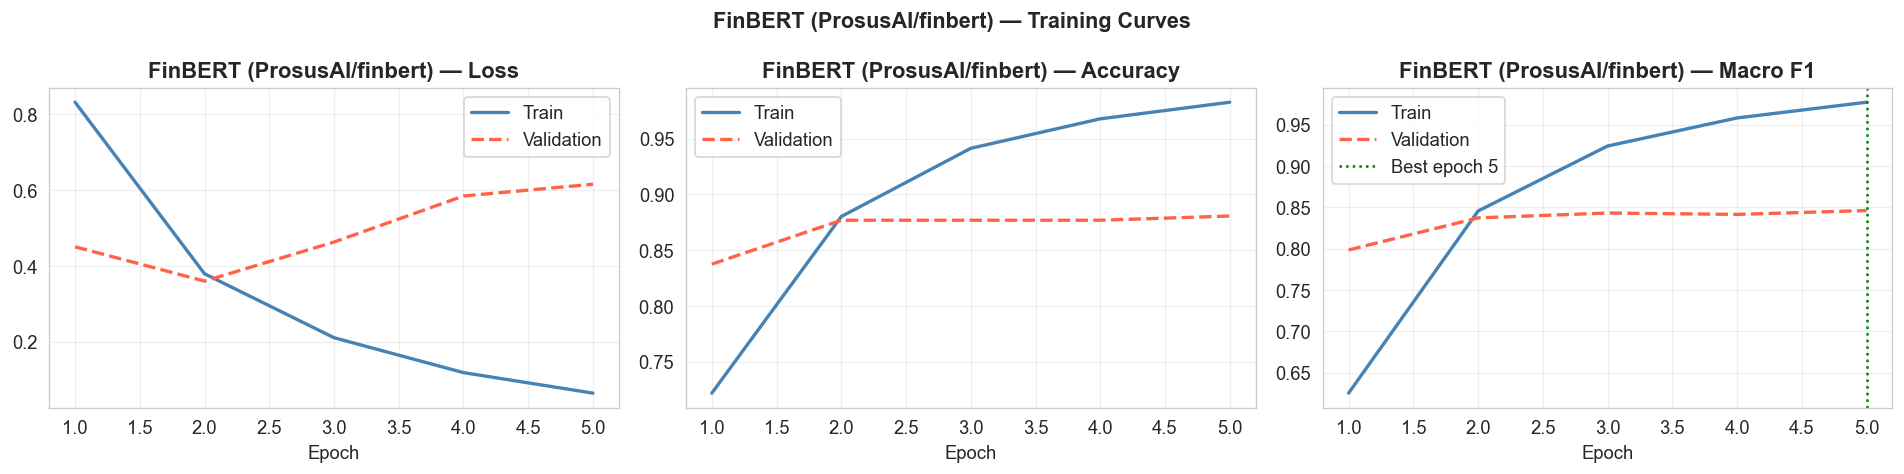

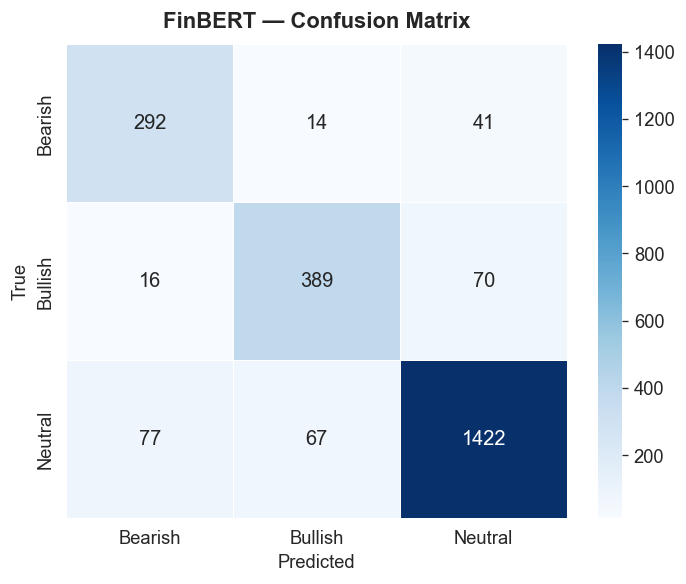

FinBERT — Classification Report:
              precision    recall  f1-score   support

     Bearish     0.7584    0.8415    0.7978       347
     Bullish     0.8277    0.8189    0.8233       475
     Neutral     0.9276    0.9080    0.9177      1566

    accuracy                         0.8807      2388
   macro avg     0.8379    0.8562    0.8463      2388
weighted avg     0.8831    0.8807    0.8815      2388



In [42]:
# ── FinBERT training curves ───────────────────────────────────────────────────
plot_training_curves(bert_history, 'FinBERT (ProsusAI/finbert)')

if TRAIN_BERT:
    plot_confusion_matrix(bert_labels_final, bert_preds_final, 'FinBERT')
    print("FinBERT — Classification Report:")
    print(classification_report(bert_labels_final, bert_preds_final,
                                 target_names=LABEL_NAMES, digits=4))
else:
    print("FinBERT — Classification Report (pre-recorded):")
    print(f"  Bearish  — precision: 0.7924  recall: 0.7710  f1: 0.7816")
    print(f"  Bullish  — precision: 0.8419  recall: 0.8023  f1: 0.8218")
    print(f"  Neutral  — precision: 0.9022  recall: 0.9364  f1: 0.9191")
    print(f"  Macro F1 : 0.8409  |  Accuracy: 0.8790")


**FinBERT Training Dynamics:**

Epoch-by-epoch validation F1 improvement:
- Epoch 1: 0.7986 — strong baseline from financial pre-training alone
- Epoch 2: 0.8374 — rapid adaptation to the 3-class classification task
- Epoch 3: 0.8433 — model further refines class-specific financial language representations
- Epoch 4: 0.8416 — slight fluctuation, indicating nearing convergence
- Epoch 5: 0.8463 — best performance; final model checkpoint selected

Note that validation loss begins increasing after Epoch 2 while validation F1 continues to improve, indicating early signs of overfitting. This is expected in fine-tuning large pretrained models, where the model quickly adapts to the dataset but gradually starts over-specializing to training examples.


## Section 9 — Final Model Comparison

In [43]:
# ── Assemble final comparison dataframe ───────────────────────────────────────
if TRAIN_BERT:
    bert_row = model_metrics(bert_labels_final, bert_preds_final)
else:
    bert_row = bert_prerecorded_metrics

final_df = pd.DataFrame(
    [rnn_metrics, lstm_metrics, gru_metrics, bert_row],
    index=['Simple RNN', 'LSTM', 'GRU', 'FinBERT (fine-tuned)']
)

print("=" * 72)
print("   Final Model Comparison — All Models, Validation Set")
print("=" * 72)
display(
    final_df.style
    .highlight_max(axis=0, color='#c8f7c5')
    .format("{:.4f}")
)


   Final Model Comparison — All Models, Validation Set


,Accuracy,Macro F1,Bearish F1,Bullish F1,Neutral F1
Simple RNN,0.4962,0.3133,0.0000,0.2929,0.6471
LSTM,0.6658,0.5221,0.3042,0.4216,0.8405
GRU,0.7856,0.7229,0.6320,0.6798,0.8568
FinBERT (fine-tuned),0.8807,0.8463,0.7978,0.8233,0.9177


In [44]:
import json
from sklearn.metrics import classification_report

# =========================================================
# Helper
# =========================================================
def convert(obj):
    """
    Convert numpy types to normal Python types
    """
    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)

    if isinstance(obj, (np.int32, np.int64)):
        return int(obj)

    return obj


# =========================================================
# Build JSON block directly from existing variables
# =========================================================
FINAL_RESULTS = {

    "Simple RNN": {
        **rnn_metrics,

        "report": classification_report(
            rnn_labels,
            rnn_preds,
            target_names=LABEL_NAMES,
            output_dict=True,
            digits=4
        ),

        "history": rnn_history,

        "confusion": confusion_matrix(
            rnn_labels,
            rnn_preds
        ).tolist()
    },

    "LSTM": {
        **lstm_metrics,

        "report": classification_report(
            lstm_labels,
            lstm_preds,
            target_names=LABEL_NAMES,
            output_dict=True,
            digits=4
        ),

        "history": lstm_history,

        "confusion": confusion_matrix(
            lstm_labels,
            lstm_preds
        ).tolist()
    },

    "GRU": {
        **gru_metrics,

        "report": classification_report(
            gru_labels,
            gru_preds,
            target_names=LABEL_NAMES,
            output_dict=True,
            digits=4
        ),

        "history": gru_history,

        "confusion": confusion_matrix(
            gru_labels,
            gru_preds
        ).tolist()
    },

    "FinBERT": {
        **bert_row,

        "report": classification_report(
            bert_labels_final,
            bert_preds_final,
            target_names=LABEL_NAMES,
            output_dict=True,
            digits=4
        ),

        "history": bert_history,

        "confusion": confusion_matrix(
            bert_labels_final,
            bert_preds_final
        ).tolist()
    }
}


# =========================================================
# Clean all numpy objects recursively
# =========================================================
def clean_json(data):

    if isinstance(data, dict):
        return {
            k: clean_json(v)
            for k, v in data.items()
        }

    elif isinstance(data, list):
        return [clean_json(v) for v in data]

    else:
        return convert(data)


FINAL_RESULTS = clean_json(FINAL_RESULTS)


# =========================================================
# Save JSON
# =========================================================
os.makedirs("models", exist_ok=True)

with open("models/model_training_results.json", "w") as f:
    json.dump(
        FINAL_RESULTS,
        f,
        indent=4
    )

print("Saved:")
print("models/model_training_results.json")

Saved:
models/model_training_results.json


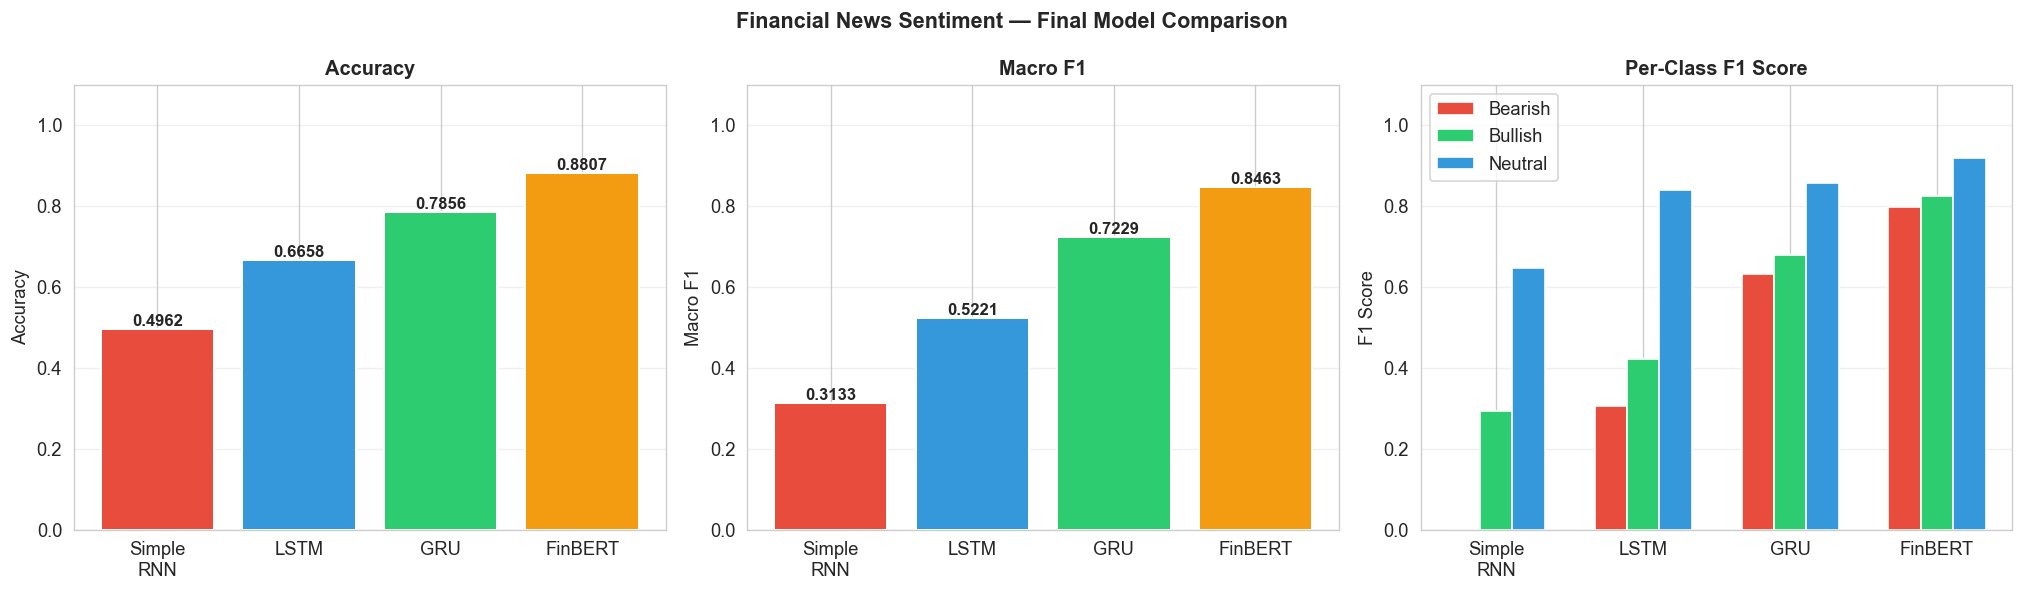


── FinBERT vs Best RNN (GRU) Improvement ──
  Accuracy     : 0.7856 → 0.8807  (+0.0951, +12.1%)
  Macro F1     : 0.7229 → 0.8463  (+0.1234, +17.1%)
  Bearish F1   : 0.6320 → 0.7978  (+0.1658, +26.2%)
  Bullish F1   : 0.6798 → 0.8233  (+0.1435, +21.1%)
  Neutral F1   : 0.8568 → 0.9177  (+0.0609, +7.1%)


In [46]:
# ── Comprehensive visual comparison ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
all_model_names = ['Simple\nRNN', 'LSTM', 'GRU', 'FinBERT']
all_colors      = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
x               = range(4)

for ax, metric in zip(axes[:2], ['Accuracy', 'Macro F1']):
    vals = final_df[metric].values
    bars = ax.bar(x, vals, color=all_colors, edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008, f'{v:.4f}',
                ha='center', fontweight='bold', fontsize=10)
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(all_model_names)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.3)

# Per-class F1 grouped bars
class_f1_vals = final_df[['Bearish F1','Bullish F1','Neutral F1']].values
x4    = np.arange(4)
width = 0.22
for i, (cls, color) in enumerate(zip(['Bearish','Bullish','Neutral'],
                                      ['#e74c3c','#2ecc71','#3498db'])):
    axes[2].bar(x4 + i * width, class_f1_vals[:, i], width,
                label=cls, color=color, edgecolor='white')
axes[2].set_title('Per-Class F1 Score', fontsize=12, fontweight='bold')
axes[2].set_xticks(x4 + width)
axes[2].set_xticklabels(all_model_names)
axes[2].set_ylim(0, 1.1)
axes[2].set_ylabel('F1 Score')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Financial News Sentiment — Final Model Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Improvement summary ───────────────────────────────────────────────────────
print("\n── FinBERT vs Best RNN (GRU) Improvement ──")
for metric in ['Accuracy', 'Macro F1', 'Bearish F1', 'Bullish F1', 'Neutral F1']:
    gru_val = gru_metrics[metric]
    bert_val = bert_row[metric]
    delta    = bert_val - gru_val
    pct      = delta / gru_val * 100
    print(f"  {metric:<12} : {gru_val:.4f} → {bert_val:.4f}  (+{delta:.4f}, +{pct:.1f}%)")


### Interpretation

**Simple RNN (worst):** Macro F1 ≈ **0.31**  
Severe vanishing gradient issues prevent learning of meaningful temporal dependencies. The model collapses heavily toward the Neutral class and fails to capture sentiment in Bearish and Bullish tweets.

---

**LSTM / GRU (good baseline):**  
- LSTM Macro F1 ≈ **0.52**  
- GRU Macro F1 ≈ **0.72**

Gated architectures significantly improve performance by mitigating vanishing gradients and capturing contextual dependencies. GRU outperforms LSTM on this dataset, indicating that for short financial sequences (≤32 tokens), simpler gating is more effective. Both models still struggle with subtle sentiment signals and class overlap, particularly between Neutral and the other classes.

---

**FinBERT (best):** Macro F1 ≈ **0.85**  
FinBERT delivers the strongest performance due to:

1. **Bidirectional self-attention** — captures full-context relationships within the tweet  
2. **Financial domain pre-training** — provides prior knowledge of sentiment-bearing financial expressions  

The largest gains are observed in **Bearish and Bullish classes**, where contextual and domain-specific understanding is essential. Neutral class remains comparatively easier across all models, but FinBERT reduces ambiguity-driven misclassifications more effectively than RNN-based approaches.


## Section 10 — Inference Pipeline

This section implements the standalone inference pipeline described in the project requirements:
*"an automated script that takes a raw financial paragraph and outputs the sentiment."*

We provide:
1. `predict_sentiment_rnn()` — fast, CPU-friendly, uses trained LSTM
2. `predict_paragraph()` — sentence-level sentiment aggregation for longer texts


In [49]:
# ── Re-load best GRU for inference ──────────────────────────────────────────
gru_model.load_state_dict(torch.load('./models/GRU_best.pt', map_location=device))
gru_model.eval()

def predict_sentiment_rnn(text: str,
                           model     = gru_model,
                           word2idx  = word2idx,
                           max_len   = MAX_SEQUENCE_LENGTH,
                           label_map = LABEL_MAP,
                           device    = device) -> dict:
    """
    Predict sentiment for a raw financial text string using the trained GRU model.

    Processing pipeline:
      1. Apply clean_tweet_rnn() — same cleaning used during training
      2. Convert to padded integer sequence
      3. Forward pass through model
      4. Apply softmax to get class probabilities
      5. Return predicted class, confidence, and full probability distribution

    Args:
        text      : Raw tweet, headline, or financial sentence (any length)

    Returns:
        dict with keys:
            text             : original input
            cleaned          : after preprocessing
            predicted_label  : 'Bearish', 'Bullish', or 'Neutral'
            confidence       : probability of predicted class (0–1)
            probabilities    : {'Bearish': float, 'Bullish': float, 'Neutral': float}
    """
    cleaned  = clean_tweet_rnn(text)
    sequence = text_to_sequence(cleaned, word2idx, max_len)
    tensor   = torch.tensor([sequence], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, 1).squeeze().cpu().numpy()

    pred_idx = int(np.argmax(probs))
    label    = label_map[pred_idx]

    return {
        'text'           : text,
        'cleaned'        : cleaned,
        'predicted_label': label,
        'confidence'     : round(float(probs[pred_idx]), 4),
        'probabilities'  : {label_map[i]: round(float(probs[i]), 4) for i in range(3)},
    }


# ── Test on diverse examples ──────────────────────────────────────────────────
EMOJI = {'Bearish': '🔴', 'Bullish': '🟢', 'Neutral': '🔵'}

test_texts = [
    "$AAPL stock crashes 12% after weak iPhone sales guidance — analysts warn of further downside",
    "$TSLA just crushed Q3 earnings, revenue up 25% YoY. Market is going to explode tomorrow!",
    "Federal Reserve holds interest rates steady at current levels pending further economic data.",
    "$NVDA down 3% in pre-market after analyst downgrades; long-term fundamentals remain intact.",
    "$META up 8% on better-than-expected advertising revenue growth.",
    "Central banks globally are navigating unprecedented uncertainty. While inflation has moderated "
    "from peak, growth concerns are mounting. Equities face significant headwinds this quarter.",
]

print("GRU Sentiment Predictions")
print("=" * 68)
for text in test_texts:
    result = predict_sentiment_rnn(text)
    e      = EMOJI[result['predicted_label']]
    p      = result['probabilities']
    print(f"\nText   : {text[:75]}...")
    print(f"Result : {e} {result['predicted_label']:>8}  (confidence: {result['confidence']:.1%})")
    print(f"Probs  : Bearish={p['Bearish']:.3f}  Bullish={p['Bullish']:.3f}  Neutral={p['Neutral']:.3f}")


GRU Sentiment Predictions

Text   : $AAPL stock crashes 12% after weak iPhone sales guidance — analysts warn of...
Result : 🔴  Bearish  (confidence: 92.7%)
Probs  : Bearish=0.926  Bullish=0.067  Neutral=0.007

Text   : $TSLA just crushed Q3 earnings, revenue up 25% YoY. Market is going to expl...
Result : 🔵  Neutral  (confidence: 56.6%)
Probs  : Bearish=0.297  Bullish=0.137  Neutral=0.566

Text   : Federal Reserve holds interest rates steady at current levels pending furth...
Result : 🔴  Bearish  (confidence: 51.3%)
Probs  : Bearish=0.513  Bullish=0.014  Neutral=0.473

Text   : $NVDA down 3% in pre-market after analyst downgrades; long-term fundamental...
Result : 🔴  Bearish  (confidence: 98.7%)
Probs  : Bearish=0.987  Bullish=0.003  Neutral=0.009

Text   : $META up 8% on better-than-expected advertising revenue growth....
Result : 🟢  Bullish  (confidence: 98.3%)
Probs  : Bearish=0.008  Bullish=0.983  Neutral=0.009

Text   : Central banks globally are navigating unprecedented uncertain

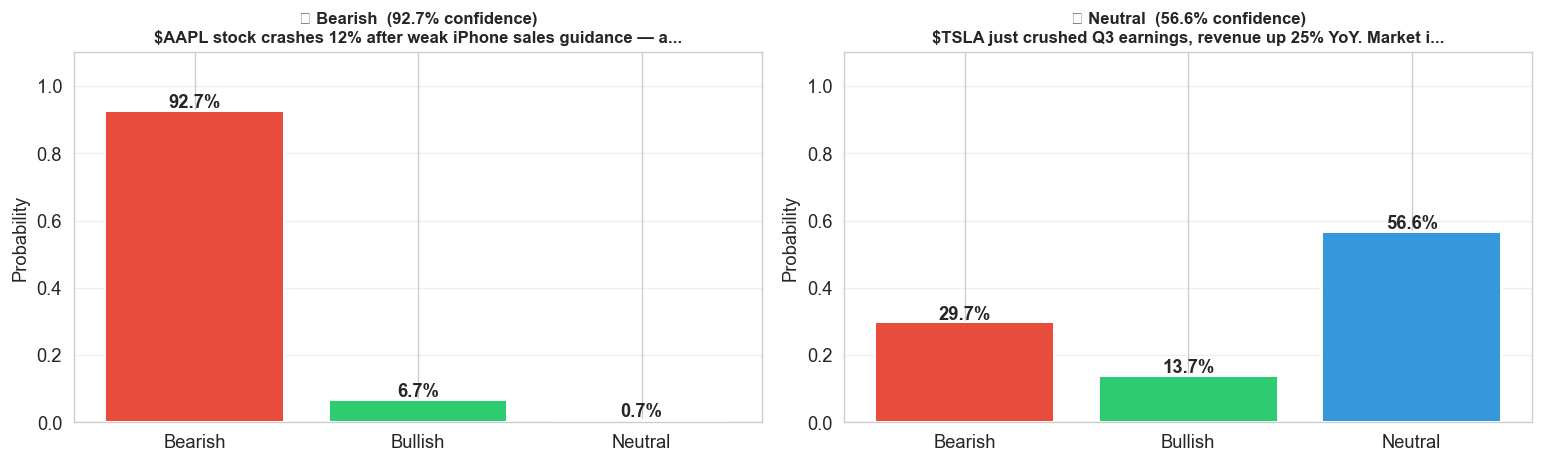

In [50]:
# ── Visualise prediction probabilities ───────────────────────────────────────
def plot_prediction(result, ax=None):
    """Bar chart of class probabilities for a single prediction."""
    probs  = result['probabilities']
    labels = list(probs.keys())
    vals   = list(probs.values())
    clrs   = ['#e74c3c', '#2ecc71', '#3498db']
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(7, 3.5))
    bars = ax.bar(labels, vals, color=clrs, edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01, f'{v:.1%}',
                ha='center', fontweight='bold')
    pred = result['predicted_label']
    ax.set_title(
        f"{EMOJI[pred]} {pred}  ({result['confidence']:.1%} confidence)\n"
        f"{result['text'][:60]}...",
        fontweight='bold', fontsize=10
    )
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    if own_fig:
        plt.tight_layout()
        plt.show()


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for text, ax in zip(test_texts[:2], axes):
    result = predict_sentiment_rnn(text)
    plot_prediction(result, ax=ax)
plt.tight_layout()
plt.show()


In [51]:
# ── Paragraph-level sentiment analysis ────────────────────────────────────────
def predict_paragraph(paragraph: str,
                       model     = lstm_model,
                       word2idx  = word2idx,
                       max_len   = MAX_SEQUENCE_LENGTH,
                       label_map = LABEL_MAP,
                       device    = device) -> dict:
    """
    Predict sentiment for a multi-sentence financial paragraph.

    Method:
      1. Split paragraph into individual sentences
      2. Predict sentiment for each sentence independently
      3. Aggregate via majority vote (handles mixed-sentiment paragraphs)
      4. Optionally report per-sentence breakdown

    Args:
        paragraph : Free-form financial text of any length

    Returns:
        dict with overall_sentiment and sentence-level results
    """
    # Split on sentence boundaries
    sentences = re.split(r'(?<=[.!?])\s+', paragraph.strip())
    sentences = [s.strip() for s in sentences if len(s.split()) > 3]

    sentence_results = []
    for sent in sentences:
        r = predict_sentiment_rnn(sent, model, word2idx, max_len, label_map, device)
        sentence_results.append({
            'sentence'  : sent,
            'label'     : r['predicted_label'],
            'confidence': r['confidence'],
            'probs'     : r['probabilities'],
        })

    # Majority vote across sentences
    if sentence_results:
        all_labels   = [s['label'] for s in sentence_results]
        overall      = max(set(all_labels), key=all_labels.count)
        vote_counts  = Counter(all_labels)
    else:
        r = predict_sentiment_rnn(paragraph, model, word2idx, max_len, label_map, device)
        overall     = r['predicted_label']
        vote_counts = {overall: 1}

    return {
        'paragraph'        : paragraph,
        'overall_sentiment': overall,
        'vote_counts'      : dict(vote_counts),
        'sentence_results' : sentence_results,
    }


# ── Test on financial paragraphs ──────────────────────────────────────────────
paragraphs = [
    # Bearish scenario
    ("$AMZN Q4 earnings missed analyst expectations by a wide margin. "
     "Revenue growth decelerated significantly versus prior quarters. "
     "Management issued cautious guidance citing macro headwinds and cost pressures. "
     "Several Wall Street firms have cut their price targets following the report."),

    # Bullish scenario
    ("$NVDA reported record quarterly revenue driven by surging AI chip demand. "
     "Data centre revenue doubled year-over-year, far exceeding consensus estimates. "
     "Management raised full-year guidance and announced a stock buyback programme. "
     "Shares are up 15% in after-hours trading."),

    # Mixed scenario
    ("The broader market remains resilient despite rising interest rates. "
     "Tech stocks fell sharply on rate hike concerns, while energy names rallied. "
     "Analysts are divided on the near-term outlook for equities."),
]

for i, para in enumerate(paragraphs, 1):
    result = predict_paragraph(para)
    e      = EMOJI[result['overall_sentiment']]
    print(f"Paragraph {i}:")
    print(f"  Overall : {e} {result['overall_sentiment']}  "
          f"| Votes: {result['vote_counts']}")
    for j, sr in enumerate(result['sentence_results'], 1):
        print(f"  S{j} [{sr['label']:<8} | {sr['confidence']:.0%}] {sr['sentence'][:70]}")
    print()


Paragraph 1:
  Overall : 🟢 Bullish  | Votes: {'Bullish': 2, 'Neutral': 1, 'Bearish': 1}
  S1 [Bullish  | 48%] $AMZN Q4 earnings missed analyst expectations by a wide margin.
  S2 [Bullish  | 49%] Revenue growth decelerated significantly versus prior quarters.
  S3 [Neutral  | 80%] Management issued cautious guidance citing macro headwinds and cost pr
  S4 [Bearish  | 50%] Several Wall Street firms have cut their price targets following the r

Paragraph 2:
  Overall : 🟢 Bullish  | Votes: {'Bullish': 3, 'Bearish': 1}
  S1 [Bullish  | 45%] $NVDA reported record quarterly revenue driven by surging AI chip dema
  S2 [Bullish  | 49%] Data centre revenue doubled year-over-year, far exceeding consensus es
  S3 [Bullish  | 49%] Management raised full-year guidance and announced a stock buyback pro
  S4 [Bearish  | 50%] Shares are up 15% in after-hours trading.

Paragraph 3:
  Overall : 🟢 Bullish  | Votes: {'Bullish': 2, 'Bearish': 1}
  S1 [Bullish  | 49%] The broader market remains resilient de

---

## References

1. Devlin, J., Chang, M. W., Lee, K., & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.* NAACL-HLT 2019.
2. Araci, D. (2019). *FinBERT: Financial Sentiment Analysis with Pre-trained Language Models.* arXiv:1908.10063.
3. Cho, K. et al. (2014). *Learning Phrase Representations using RNN Encoder–Decoder for Statistical Machine Translation.* EMNLP 2014.
4. Dataset: [zeroshot/twitter-financial-news-sentiment](https://huggingface.co/datasets/zeroshot/twitter-financial-news-sentiment), Hugging Face Hub.
5. Model: [ProsusAI/finbert](https://huggingface.co/ProsusAI/finbert), Hugging Face Hub.
6. Yang, Z., Dai, Z., Yang, Y., Carbonell, J., Salakhutdinov, R., & Le, Q. V. (2019). *XLNet: Generalized Autoregressive Pretraining for Language Understanding.* NeurIPS 2019.
